# NASA Landslide & Perciptation Analysis 

## IST 652

### Gary Dhillon

Landslides are considered to be a disastrous, globally occurring natural hazard that has been leading to significant human and economic losses each year. The **NASA Global Landslide Catalog** provides detailed event-level data on landslides worldwide, including event dates, geographic location, type of landslide, potential triggers, and reported fatalities or injuries.  

The analysis will showcase a variety of techniques to explore the global landslide data and gain an understanding of their frequency, severity, and underlying causes. The global landslide data analysis will also be supplemented by an external dataset, which will include precipitation from the **NASA POWER Project**, and will allow an examination into how annual rainfall patterns may influence landslide frequency.   

Questions addressed by the analysis will include:  
- Which types of landslides occur most frequently?  
- Which categories are associated with the most fatalities?  
- In which regions and seasons do landslides occur most often?  
- How do man-made triggers compare with natural ones?  
- What is the relationship between rainfall and landslide occurrence?  

## Overview of Raw Data:
The two datasets which will be used for the project are formatted as CSV files and can be found on Kaggle. The Global Landslide Catalog dataset can be found on https://www.kaggle.com/datasets/pratul007/global-landslide-catalog-export, and the percipitation dataset from the NASA POWER Project can be found on https://www.kaggle.com/datasets/poojag718/rainfall-timeseries-data.

**File:** `Global_Landslide_Catalog_Export.csv`  
- Source: NASA’s Global Landslide Catalog.  
- Scope: Worldwide records of reported landslides.  
- Key variables:  
  - **event_date / event_time** – when the event occurred.  
  - **latitude / longitude** – geographic coordinates.  
  - **country_name** – reported country.  
  - **landslide_category** – broad type of landslide (e.g., mudslide, rockfall).  
  - **landslide_trigger** – what initiated the event (e.g., rainfall, earthquake, storm).  
  - **landslide_size** – categorical estimate of size (small to catastrophic).  
  - **storm_name** – associated storm if reported.  
  - **fatality_count / injury_count** – reported human impacts.  
  - **source_name / source_link** – reporting outlet.  

This dataset provides the foundation for exploratory analysis, visualizations, and modeling.

**File:** `Rainfall_data.csv`  
- Source: Kaggle dataset derived from **NASA POWER (Prediction of Worldwide Energy Resources)** project.  
- Scope: Daily precipitation records aggregated from the MERRA-2 assimilation model.  
- Key variables:  
  - **Year** – calendar year of the record.  
  - **Month / Day** – daily breakdown of precipitation.  
  - **Precipitation** – precipitation level (mm/day).  

This dataset allows investigation of how **annual rainfall totals** correspond to global landslide frequency and severity when merged with the landslide catalog. 

In [120]:
# Loading in all necessary packages that will be needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import re
import nltk
import warnings
warnings.filterwarnings("ignore")
from sklearn.pipeline import Pipeline
from scipy.stats import linregress
from shapely.geometry import Point
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud, STOPWORDS

## Data Cleaning and Preprocessing (Global Landslide Catalog)

In [121]:
# Load the initial dataset
df = pd.read_csv("Global_Landslide_Catalog_Export.csv")

The Global Landslide Catalog is loaded using `pd.read_csv()`

In [122]:
def read_landslides(df):
    
    """
    Cleans and extracts datetime features from the 'event_date' column.
    
    Returns columns for event_date, time, year, month, and hour.
    """
    df['event_datetime'] = pd.to_datetime(df['event_date'], errors='coerce')
    df['event_date'] = df['event_datetime'].dt.date
    df['event_time'] = df['event_datetime'].dt.strftime('%H:%M:%S')
    df['event_year'] = df['event_datetime'].dt.year
    df['event_month'] = df['event_datetime'].dt.month
    df['event_hour'] = df['event_datetime'].dt.hour
    
    return df

The preparation of the dataset for analysis and modeling required a custom function which we named `read_landslides()`. This was created to clean and standardize the `event_date` column. 

In [123]:
# Clean the dataset and extract datetime features
clean_landslides = read_landslides(df)

In [124]:
# Calling the dataframe
clean_landslides

,source_name,source_link,event_id,event_date,event_time,event_title,event_description,location_description,location_accuracy,landslide_category,...,gazeteer_distance,submitted_date,created_date,last_edited_date,longitude,latitude,event_datetime,event_year,event_month,event_hour
0,AGU,https://blogs.agu.org/landslideblog/2008/10/14...,684,2008-08-01,00:00:00,"Sigou Village, Loufan County, Shanxi Province","occurred early in morning, 11 villagers buried...","Sigou Village, Loufan County, Shanxi Province",unknown,landslide,...,41.02145,04/01/2014 12:00:00 AM,11/20/2017 03:17:00 PM,02/15/2018 03:51:00 PM,107.450000,32.562500,2008-08-01 00:00:00,2008,8,0
1,Oregonian,http://www.oregonlive.com/news/index.ssf/2009/...,956,2009-01-02,02:00:00,"Lake Oswego, Oregon",Hours of heavy rain are to blame for an overni...,"Lake Oswego, Oregon",5km,mudslide,...,0.60342,04/01/2014 12:00:00 AM,11/20/2017 03:17:00 PM,02/15/2018 03:51:00 PM,-122.663000,45.420000,2009-01-02 02:00:00,2009,1,2
2,CBS News,https://www.cbsnews.com/news/dozens-missing-af...,973,2007-01-19,00:00:00,"San Ramon district, 195 miles northeast of the...",(CBS/AP) At least 10 people died and as many a...,"San Ramon district, 195 miles northeast of the...",10km,landslide,...,0.85548,04/01/2014 12:00:00 AM,11/20/2017 03:17:00 PM,02/15/2018 03:51:00 PM,-75.358700,-11.129500,2007-01-19 00:00:00,2007,1,0
3,Reuters,https://in.reuters.com/article/idINIndia-41450...,1067,2009-07-31,00:00:00,Dailekh district,"One person was killed in Dailekh district, pol...",Dailekh district,unknown,landslide,...,0.75395,04/01/2014 12:00:00 AM,11/20/2017 03:17:00 PM,02/15/2018 03:51:00 PM,81.708000,28.837800,2009-07-31 00:00:00,2009,7,0
4,The Freeman,http://www.philstar.com/cebu-news/621414/lands...,2603,2010-10-16,12:00:00,sitio Bakilid in barangay Lahug,Another landslide in sitio Bakilid in barangay...,sitio Bakilid in barangay Lahug,5km,landslide,...,2.02204,04/01/2014 12:00:00 AM,11/20/2017 03:17:00 PM,02/15/2018 03:51:00 PM,123.897800,10.333600,2010-10-16 12:00:00,2010,10,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11028,The Jakarta Post,http://www.thejakartapost.com/news/2017/04/02/...,11109,2017-04-01,13:34:00,Major landslide in Banaran,Landslide exacerbated by deforestation and bad...,"Banaran, Ponorogo, Jawa Timur, Indonesia",5km,landslide,...,NaN,07/28/2017 01:34:00 PM,12/19/2017 09:42:00 PM,02/15/2018 03:51:00 PM,111.679944,-7.853409,2017-04-01 13:34:00,2017,4,13
11029,Greater Kashmir,http://www.greaterkashmir.com/news/jammu/lands...,10845,2017-03-25,17:32:00,Barnari Sigdi Landslide,Two teenage girls died after they were buried ...,"Barnari Sigdi area, Tehsil Mughalmaidan, Kisht...",5km,landslide,...,NaN,09/21/2017 05:32:00 PM,12/05/2017 06:45:00 PM,02/15/2018 03:51:00 PM,75.680611,33.403080,2017-03-25 17:32:00,2017,3,17
11030,NBC Daily,http://www.nbcdaily.com/separate-landslides-ki...,10973,2016-12-15,05:00:00,Landslide at Pub Sarania Hill,An octogenarian was killed when a sudden lands...,"Pub Sarania Hill, Guwahati, Assam, India",1km,landslide,...,NaN,07/26/2017 01:22:00 PM,12/08/2017 08:37:00 PM,02/15/2018 03:51:00 PM,91.772042,26.181606,2016-12-15 05:00:00,2016,12,5
11031,AGU Landslide Blog,http://blogs.agu.org/landslideblog/2017/05/02/...,10901,2017-04-29,19:03:00,Mayor landslide at Ayu village,Landslide triggered by heavy rainfall buried 1...,"Ayu, Ozgon, Osh, Kyrgyzstan",1km,translational_slide,...,NaN,07/14/2017 07:03:00 PM,12/07/2017 09:19:00 PM,02/15/2018 03:51:00 PM,73.472379,40.886395,2017-04-29 19:03:00,2017,4,19


Upon calling the dataframe, we can see that we now have 11,033 rows consisting of 35 different columns. The next step will return all of the names of the columns in the respective dataframe

In [125]:
# Taking a peek at the columns we now have 
clean_landslides.columns

Index(['source_name', 'source_link', 'event_id', 'event_date', 'event_time',
       'event_title', 'event_description', 'location_description',
       'location_accuracy', 'landslide_category', 'landslide_trigger',
       'landslide_size', 'landslide_setting', 'fatality_count', 'injury_count',
       'storm_name', 'photo_link', 'notes', 'event_import_source',
       'event_import_id', 'country_name', 'country_code',
       'admin_division_name', 'admin_division_population',
       'gazeteer_closest_point', 'gazeteer_distance', 'submitted_date',
       'created_date', 'last_edited_date', 'longitude', 'latitude',
       'event_datetime', 'event_year', 'event_month', 'event_hour'],
      dtype='object')

In [126]:
# Quick check: show unique event hours
print("Sample hours:", sorted(clean_landslides['event_hour'].dropna().unique()))

Sample hours: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23)]


The event hours show that we have landslide events occurring at each hour of the day. The values that are returned represent increments on a 24-hour clock.

In [127]:
# Quick check: missing values per column
missing_summary = clean_landslides.isna().sum().reset_index()
missing_summary.columns = ["column", "missing_count"]
print(missing_summary.sort_values("missing_count", ascending=False).head(15))

                       column  missing_count
17                      notes          10716
15                 storm_name          10456
16                 photo_link           9537
14               injury_count           5674
22        admin_division_name           1637
21               country_code           1564
18        event_import_source           1563
24     gazeteer_closest_point           1563
20               country_name           1562
23  admin_division_population           1562
25          gazeteer_distance           1562
19            event_import_id           1562
13             fatality_count           1385
6           event_description            862
1                 source_link            846


An assessment of missing values was conducted to understand data completeness across key columns. Several features, including `notes`, `storm_name`, `photo_link`, and `injury_count`, contain a significant number of null entries. These columns may either be dropped, imputed, or excluded from modeling depending on their importance and the proportion of missingness.

Understanding which fields are incomplete helps guide decisions for feature selection, imputation strategies, or potential exclusions during model training.

In [128]:
def check_date_column(df, column: str = "event_date"):
    """
    Check for missing values in a date column and print summary info.

    If missing values exist, prints their count.
    Otherwise, prints the range of dates (min to max).
    """
    missing_count = df[column].isna().sum()
    if missing_count > 0:
        print(f"There are {missing_count} missing {column} values.")
    else:
        min_date = df[column].min()
        max_date = df[column].max()
        print(f"{column} range: {min_date} - {max_date}")

In [129]:
# Checking event ranges of our data
check_date_column(clean_landslides, "event_date")

event_date range: 1988-11-07 - 2017-09-28


The dataset spans nearly three decades of reported landslide events, with dates ranging from **November 7, 1988** to **September 28, 2017**. This wide temporal coverage allows for analysis of long-term trends, seasonal patterns, and changes in landslide occurrence over time.

In [130]:
# Checking to see if we have NAs for event dates
event_date_nas = clean_landslides['event_date'].isna().sum()
print(f"Event Date NAs: {event_date_nas}")

Event Date NAs: 0


In [131]:
# Checking to see if we have NAs for event timesamps
event_timestamp_nas = clean_landslides['event_datetime'].isna().sum()
print(f"Event Timestamp NAs: {event_timestamp_nas}")

Event Timestamp NAs: 0


All events appear to have valid dates and timestamps since the results returned 0 NAs.

In [132]:
clean_landslides.describe()

,event_id,fatality_count,injury_count,event_import_id,admin_division_population,gazeteer_distance,longitude,latitude,event_datetime,event_year,event_month,event_hour
count,11033.000000,9648.000000,5359.000000,9471.000000,9.471000e+03,9471.000000,11033.000000,11033.000000,11033,11033.000000,11033.000000,11033.000000
mean,5598.953141,3.219424,0.751819,4798.563070,1.577600e+05,11.873689,2.520441,25.881887,2013-03-12 05:19:56.432520704,2012.703979,6.410677,6.842926
min,1.000000,0.000000,0.000000,-111.167300,0.000000e+00,0.000030,-179.980766,-46.774800,1988-11-07 00:00:00,1988.000000,1.000000,0.000000
25%,2785.000000,0.000000,0.000000,2386.500000,1.963000e+03,2.363845,-107.871700,13.917600,2010-11-09 00:00:00,2010.000000,3.000000,0.000000
50%,5563.000000,0.000000,0.000000,4773.000000,7.365000e+03,6.254870,19.694600,30.534500,2013-07-12 00:00:00,2013.000000,7.000000,0.000000
75%,8435.000000,1.000000,0.000000,7189.500000,3.402100e+04,15.815610,93.948000,40.866259,2015-10-19 00:00:00,2015.000000,9.000000,14.000000
max,11221.000000,5000.000000,374.000000,9669.000000,1.269184e+07,215.448880,179.991364,72.627500,2017-09-28 19:36:00,2017.000000,12.000000,23.000000
std,3249.228647,59.886178,8.458955,2789.125559,8.297345e+05,15.598228,100.908393,20.415054,NaN,3.006688,3.348912,8.052497


To understand the distribution and scale of numeric features in the dataset, the `.describe()` method was applied. This provides statistical summaries such as count, mean, standard deviation, min/max values, and quartiles for relevant numerical columns.

Key observations include:
- The dataset contains over 11,000 events, with `fatality_count` ranging from 0 to 5000 and `injury_count` up to 374.
- Geographic coordinates (`latitude`, `longitude`) span a global range, confirming the international coverage of the dataset.
- Temporal features (`event_year`, `event_month`, `event_hour`) were successfully extracted and are shown to be well-distributed across their expected ranges.

These statistics only apply to **numerical columns**, and do not reflect distributions of categorical or text-based fields such as `event_title`, `event_description`, or `source_name`.

## Data Analysis and Models (Global Landslide Catalog)

In [133]:
def aggregate_counts(df, column):
    """
    Group by a column and return counts as a DataFrame.
    
    """
    return df.groupby(column).size().reset_index(name='count')

In [134]:
# Aggregating landslide events by hourly and monthly
hourly_counts = aggregate_counts(clean_landslides, "event_hour")
monthly_counts = aggregate_counts(clean_landslides, "event_month")

In [135]:
def plot_count_by_column(df, column, title=None, xlabel=None, ylabel="Count", figsize=(12,6)):
    """
    Create a countplot for a categorical/numeric column.
    

    """
    sns.set(style="whitegrid")
    plt.figure(figsize=figsize)
    sns.countplot(data=df, x=column, color="steelblue")
    
    plt.title(title if title else f"Number of Landslides by {column}", fontsize=16)
    plt.xlabel(xlabel if xlabel else column, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    
    if column == "event_hour":
        plt.xticks(range(0, 24))  # hour-specific tweak
    
    plt.tight_layout()
    plt.show()

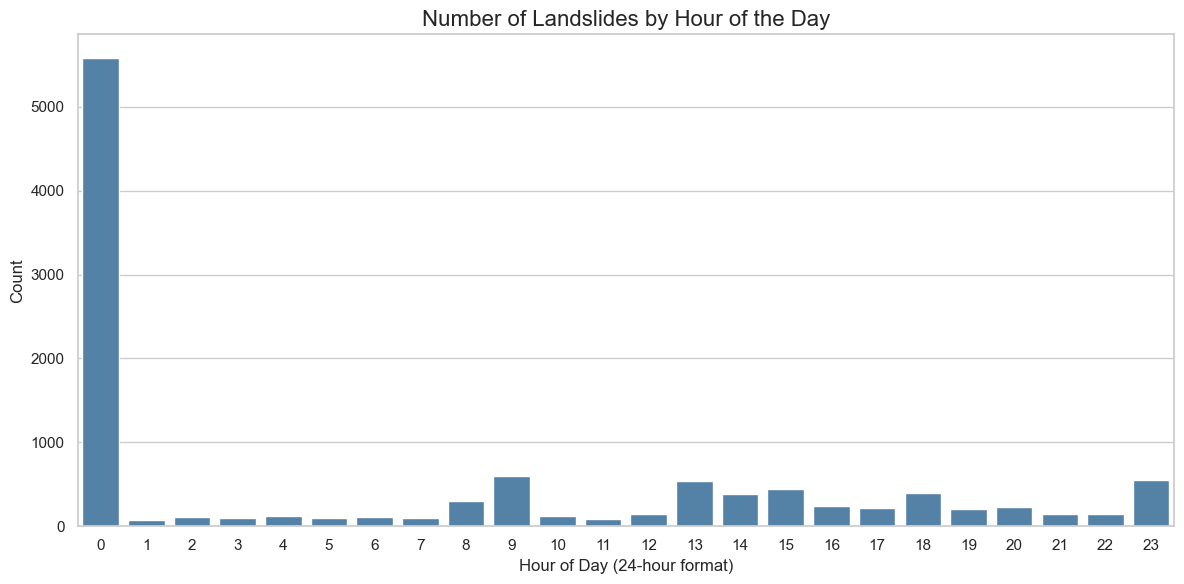

In [136]:
# Plotting bar chart showcasing number of landslides by hour of day
plot_count_by_column(clean_landslides, "event_hour", 
                     title="Number of Landslides by Hour of the Day", 
                     xlabel="Hour of Day (24-hour format)")

The bar chart above illustrates the number of reported landslides by hour (in 24-hour format). A significant spike occurs at hour 0 (midnight), which may not reflect actual event timing but rather a default or missing time entry in the original dataset.

Aside from that, landslide occurrences appear relatively spread out across the day, with slight increases in the early morning and late afternoon hours. These patterns could suggest real-world temporal trends or be influenced by inconsistent time reporting across sources and regions.

This observation highlights the importance of critically evaluating temporal fields, especially when null or imprecise time values may be defaulted to midnight.

In [137]:
def check_placeholder_count(df, column, placeholder="00:00:00"):
    """
    Check how often a placeholder value appears in a column.
    

    """
    placeholder_mask = df[column].astype(str).str.strip() == placeholder
    count = placeholder_mask.sum()
    proportion = count / df.shape[0]
    
    print(f"Rows with {column} = '{placeholder}': {count}")
    print(f"Proportion of total: {proportion:.4f}")
    return count, proportion

In [138]:
# Seeing how many rows show a default time of '00:00:00'
check_placeholder_count(clean_landslides, "event_time", "00:00:00")

Rows with event_time = '00:00:00': 5533
Proportion of total: 0.5015


(np.int64(5533), np.float64(0.5014955134596212))

To investigate the spike in reported landslide events at midnight (`00:00:00`), a check was performed to count how many rows had this specific time value. The results showed that **5,533 events**, or approximately **50.15%** of the dataset, had a timestamp of `00:00:00`. This strongly suggests that many of these time entries are likely placeholders used when the exact time of the event was unknown or unreported.

In [139]:
def filter_placeholder_time(df, time_column="event_time", date_column="event_date", placeholder="00:00:00"):
    """
    Remove rows with placeholder time values (e.g., "00:00:00") 
    and report the valid date range.
    
    
    """
    filtered = df[df[time_column] != placeholder].copy()
    min_date = filtered[date_column].min()
    max_date = filtered[date_column].max()
    
    print(f"Valid {date_column} range after filtering '{placeholder}': {min_date} to {max_date}")
    return filtered

In [140]:
timed_slides = filter_placeholder_time(clean_landslides)

Valid event_date range after filtering '00:00:00': 1993-06-04 to 2017-09-28


After running our function, we can see that there are no timed landslides existing before 1993.

In [141]:
def plot_counts(df, column, title=None, xlabel=None, ylabel="Count", figsize=(12,6), color="teal", rotation=0):
    """
    Plot counts by a given column using a bar chart.
   
    """
    plt.figure(figsize=figsize)
    sns.barplot(data=df, x=column, y="count", color=color)
    plt.title(title if title else f"Count by {column}", fontsize=16)
    plt.xlabel(xlabel if xlabel else column, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()

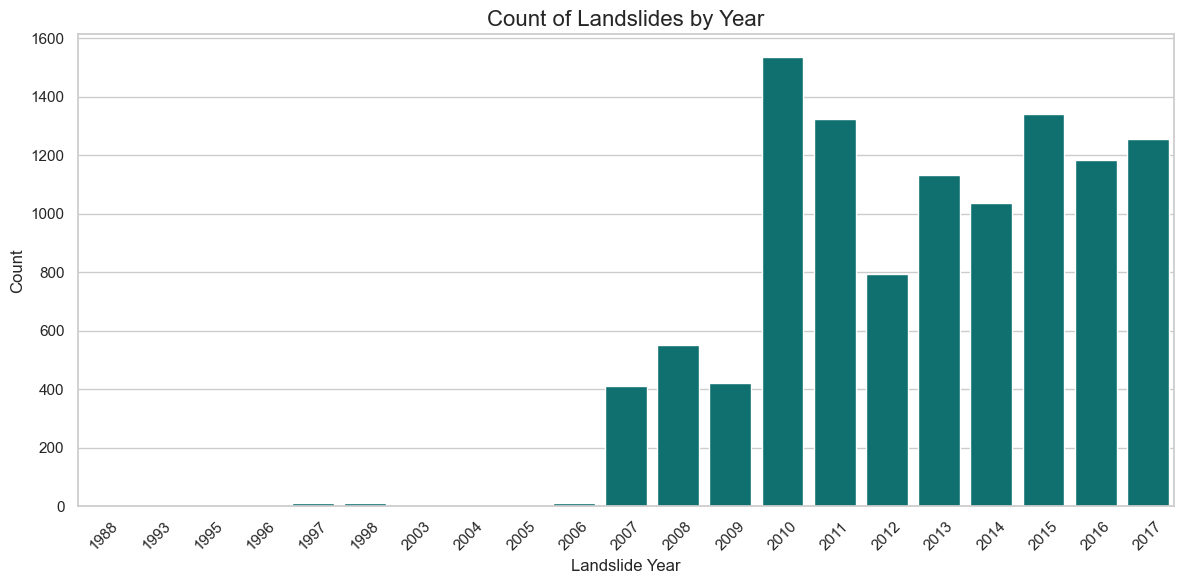

In [142]:
sum_slides = aggregate_counts(clean_landslides, "event_year")
plot_counts(sum_slides, "event_year", title="Count of Landslides by Year", xlabel="Landslide Year", rotation=45)

The bar chart shows the number of recorded landslides per year (1988–2017).

**Sparse records prior to 2006**: Very few landslides appear before 2006, suggesting gaps in reporting or limited data collection rather than a true absence of events.

**Sharp rise after 2007**: Starting around 2007, recorded landslides increase significantly, peaking in 2010 with more than 1,500 events.

**Consistently high activity afterward**: From 2010 onward, annual landslide counts remain elevated, indicating a shift toward more comprehensive monitoring and/or higher reporting frequency.

This visualization highlights the temporal distribution of landslides, showing that the late 2000s and 2010s were the most active years in the dataset. 

In [143]:
def filter_nonempty(df, column):
    """
    Filter rows where a column is not null/empty.
    
    """
    return df[df[column].notna() & (df[column].astype(str).str.strip() != "")]

In [144]:
def plot_time_series(df, x, y, title=None, xlabel=None, ylabel=None, color="purple", marker="o", rotation=45, figsize=(12,6)):
    """
    Plot a time series line chart with seaborn.
    

    """
    plt.figure(figsize=figsize)
    sns.lineplot(data=df, x=x, y=y, marker=marker, color=color)
    plt.title(title if title else f"{y} over {x}", fontsize=16)
    plt.xlabel(xlabel if xlabel else x, fontsize=12)
    plt.ylabel(ylabel if ylabel else y, fontsize=12)
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()

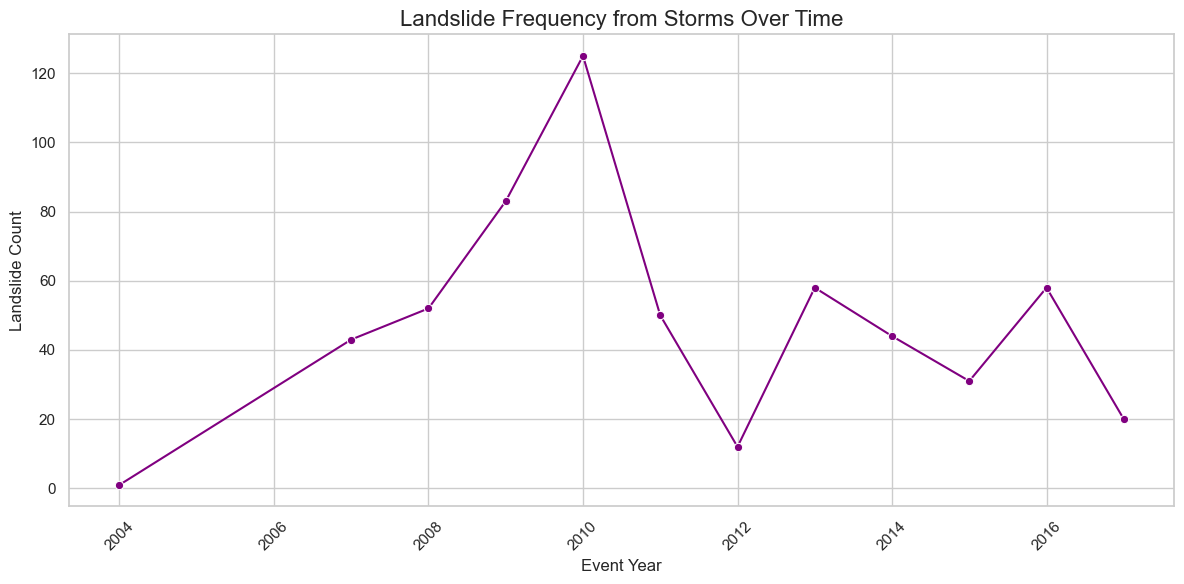

In [145]:
storm_filtered = filter_nonempty(clean_landslides, "storm_name")
year_subset = aggregate_counts(storm_filtered, "event_year").rename(columns={"count": "event_count"})
plot_time_series(year_subset, "event_year", "event_count", 
                 title="Landslide Frequency from Storms Over Time", 
                 xlabel="Event Year", ylabel="Landslide Count")

This visualization shows the frequency of storm-triggered landslides from 2004–2017.

**Rising activity through the late 2000s**: Counts steadily increase, reaching a peak in 2010 with over 120 storm-related events.

**Fluctuations afterward**: After 2010, the number of storm-triggered landslides declines, but there are noticeable secondary peaks in 2013 and 2016.

**Temporal insight**: The pattern suggests that storm-related landslides tend to cluster in certain years, likely reflecting periods of particularly intense storm activity.

Ultimately, we can see from the chart that storm-driven landslides do have some year-by-year variability .

In [146]:
def to_geodataframe(df, lon_col="longitude", lat_col="latitude", crs="EPSG:4326"):
    """
    Convert a DataFrame with longitude/latitude into a GeoDataFrame.
    
    """
    geometry = [Point(xy) for xy in zip(df[lon_col], df[lat_col])]
    return gpd.GeoDataFrame(df, geometry=geometry, crs=crs)

In [147]:
def plot_world_events(geo_df, shapefile="world_shapefile/world_shapefile/ne_110m_admin_0_countries.shp",
                      color="red", column=None, cmap="viridis",
                      markersize=5, alpha=0.6, figsize=(15,10), title="Event Locations"):
    """
    Plot world map with event locations overlayed. Optionally color by a column.
    """
    world = gpd.read_file(shapefile)
    fig, ax = plt.subplots(figsize=figsize)
    world.plot(ax=ax, color="lightgray", edgecolor="white")

    if column:
        geo_df.plot(ax=ax, marker="o", column=column, cmap=cmap, markersize=markersize, alpha=alpha, legend=True)
    else:
        geo_df.plot(ax=ax, marker="o", color=color, markersize=markersize, alpha=alpha)

    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    plt.tight_layout(); plt.show()

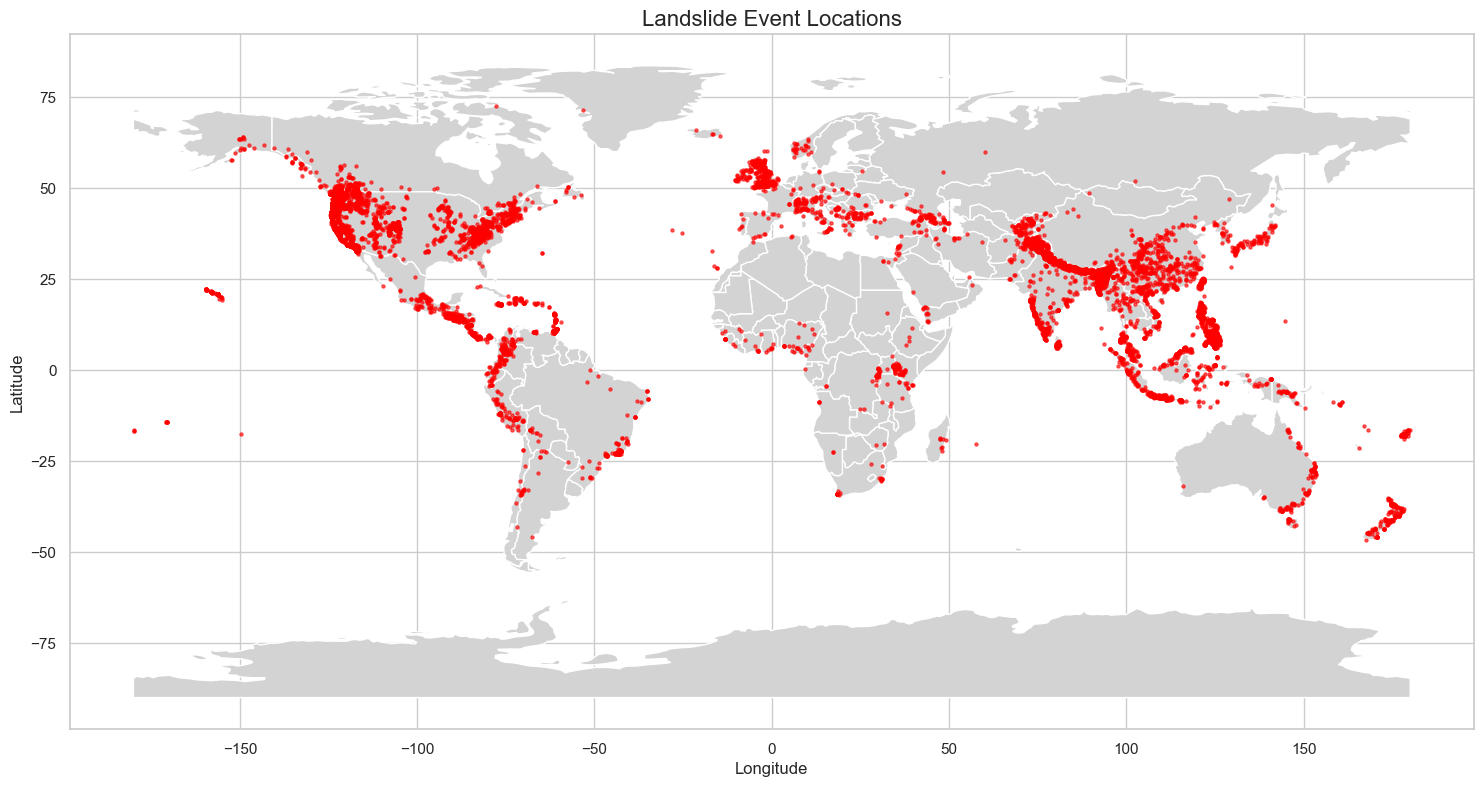

In [148]:
geo_df = to_geodataframe(clean_landslides)
plot_world_events(geo_df, title="Landslide Event Locations") # plot landslide event locations across the globe

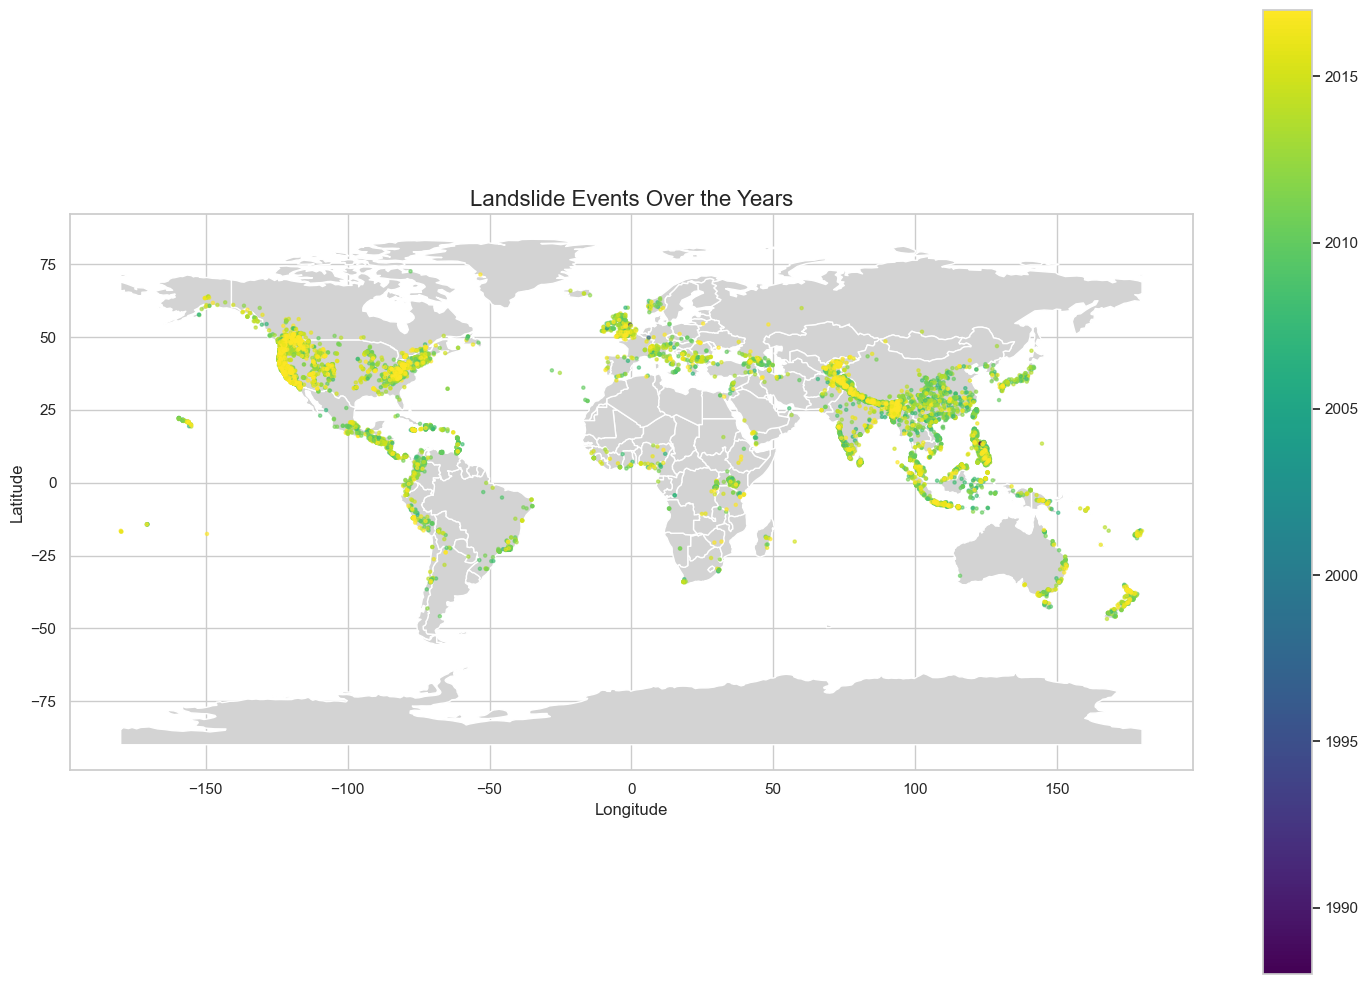

In [149]:
plot_world_events(geo_df, column="event_year", title="Landslide Events Over the Years") # plot landslide events by year

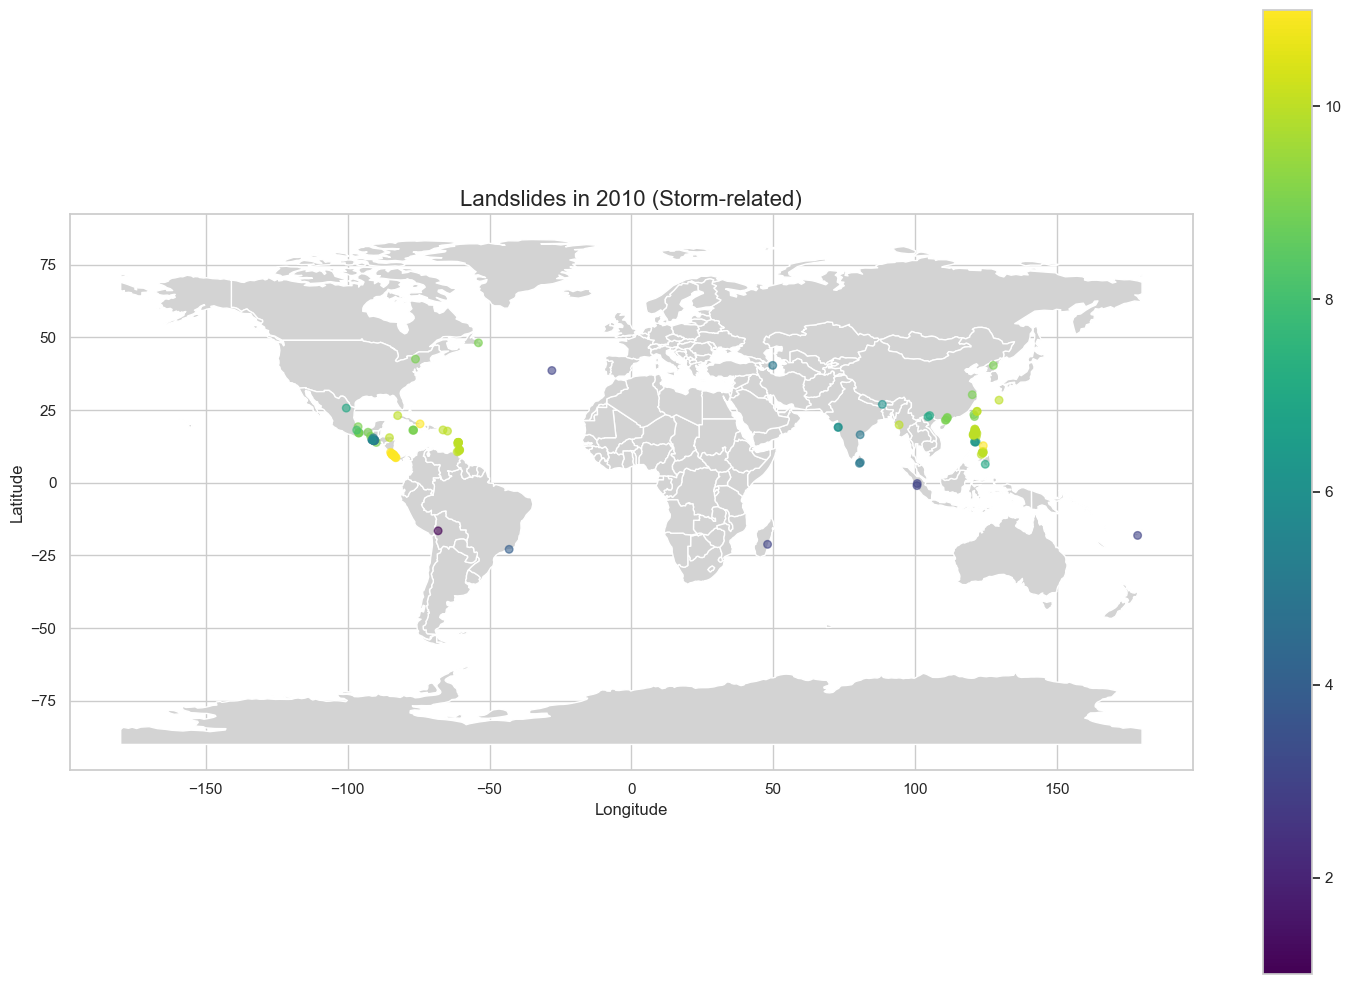

In [150]:
# storms in 2010
storm_2010 = filter_nonempty(clean_landslides, "storm_name").query("event_year == 2010")
storm_2010_gdf = to_geodataframe(storm_2010)

# plot storms in 2010
plot_world_events(
    storm_2010_gdf,
    column="event_month", cmap="viridis", markersize=30,
    title="Landslides in 2010 (Storm-related)"
)

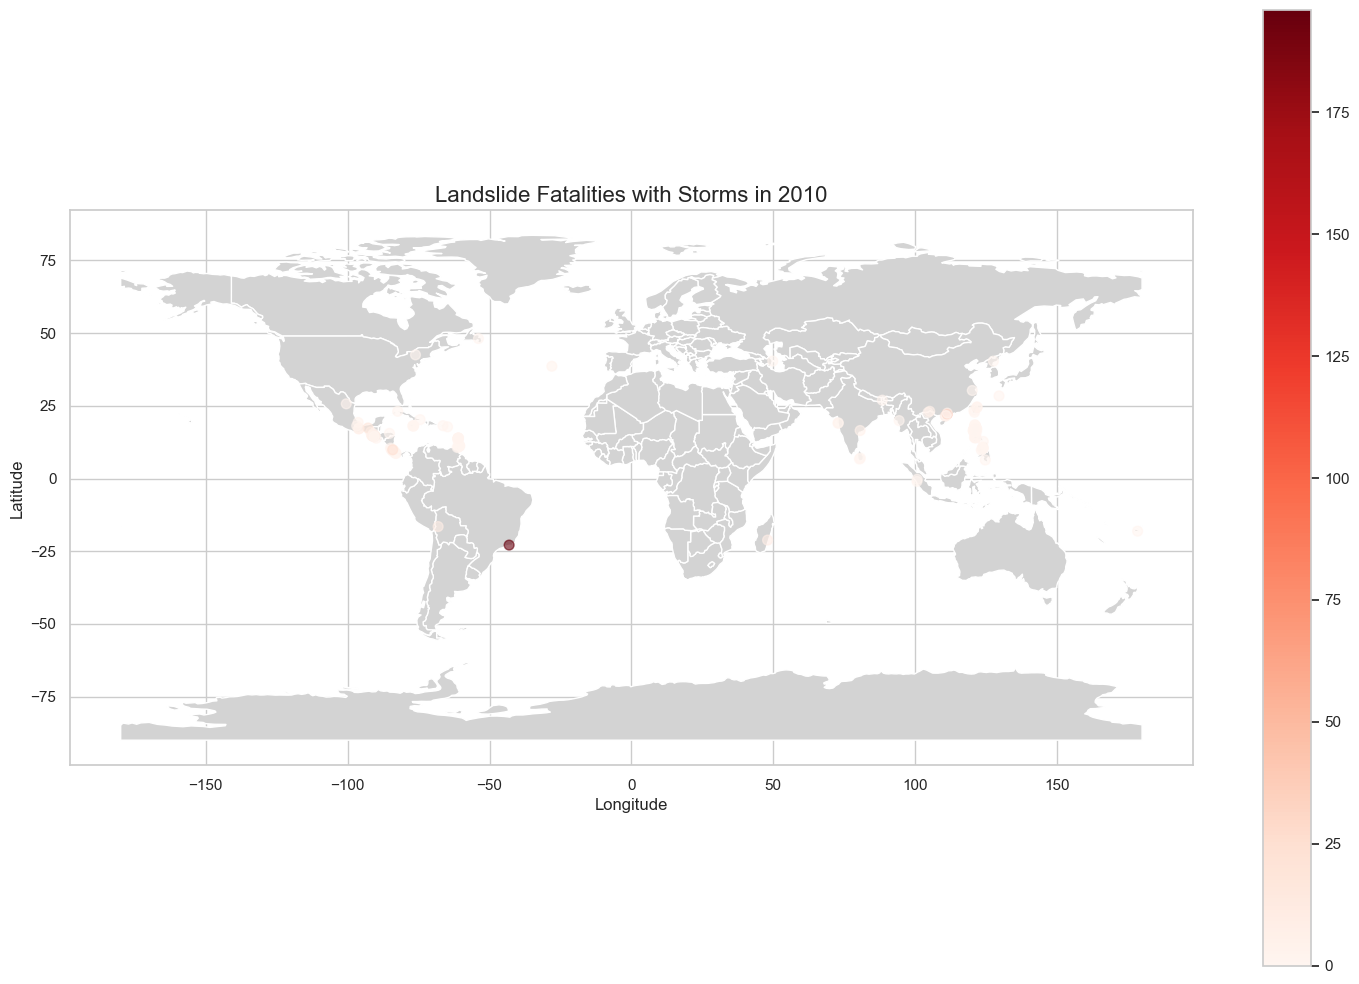

In [151]:
# Filter storms in 2010
storm_2010 = filter_nonempty(clean_landslides, "storm_name").query("event_year == 2010")

# Convert to GeoDataFrame
storm_2010_gdf = to_geodataframe(storm_2010)

# Plot by fatality_count
plot_world_events(
    storm_2010_gdf,
    column="fatality_count", cmap="Reds",
    markersize=50, title="Landslide Fatalities with Storms in 2010"
)

The sequence of maps provides both a global and temporal perspective on landslide activity.

**Map #1** shows the worldwide distribution of landslide events, with clear concentrations in South Asia, Southeast Asia, Central America, and the Pacific Northwest.

**Map #2**, colored by year, highlights the steady growth in reported events over time, culminating in a marked spike around 2010.

**Map #3** zooms in on storm-related landslides in 2010, reinforcing how extreme weather events were a key driver of the surge that year.

**Map #4** focuses specifically on fatalities from storm-triggered landslides in 2010, showing that while landslides occurred globally, the most severe impacts were concentrated in regions such as South America and South Asia.

Taken together, these visualizations address the hypothesis question:
“In which regions and seasons do landslides occur most often?”

The evidence suggests that landslides are most frequent in tropical and subtropical regions prone to heavy rainfall and storm activity, with 2010 representing a particularly deadly year. This highlights the dual importance of both geography (where) and climate patterns (when) in shaping global landslide risk.

In [152]:
def filter_outliers(df, column, upper=None, quantile=None):
    """
    Remove outliers by absolute upper bound OR by quantile cap.
    
    """
    if quantile is not None:
        upper = df[column].quantile(quantile)
    return df[df[column] <= upper].copy()

def aggregate_sum(df, group_col, value_col, sort_desc=True):
    """
    Group by a column and sum another column.
    
    """
    out = df.groupby(group_col, dropna=False)[value_col].sum().reset_index()
    return out.sort_values(value_col, ascending=not sort_desc)

def plot_bar(df, x, y, title, xlabel=None, ylabel=None, rotation=0, figsize=(12,6)):
    plt.figure(figsize=figsize)
    sns.barplot(data=df, x=x, y=y)
    plt.title(title, fontsize=16)
    plt.xlabel(xlabel or x); plt.ylabel(ylabel or y)
    plt.xticks(rotation=rotation)
    plt.tight_layout(); plt.show()

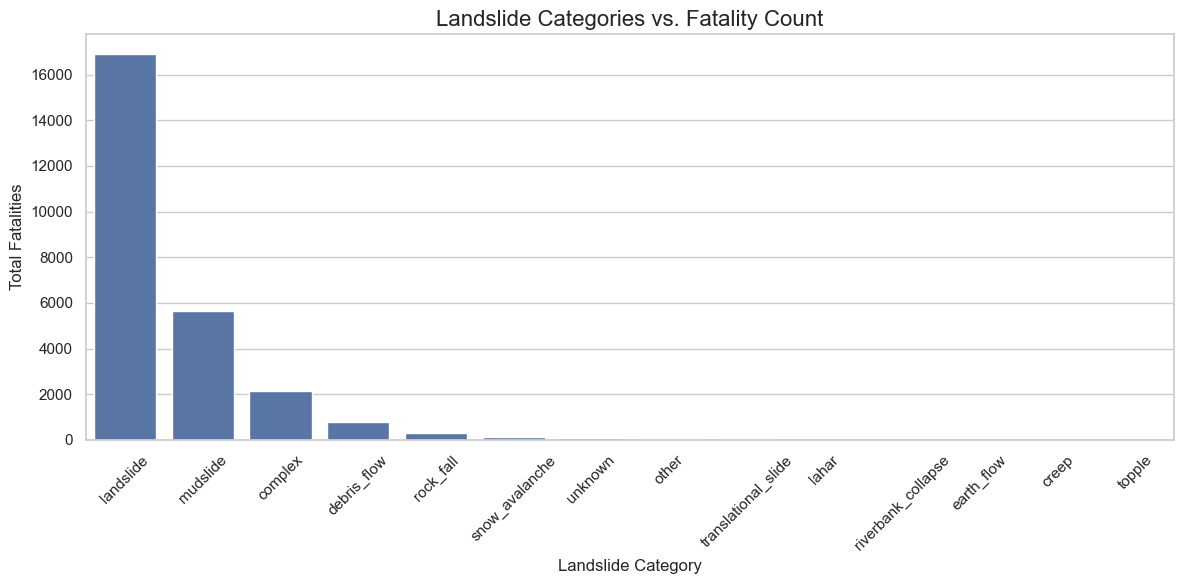

In [153]:
# filter out extreme outlier(s)
subset = filter_outliers(clean_landslides, "fatality_count", upper=4000)

# aggregate fatalities by category
category_fatalities = aggregate_sum(subset, "landslide_category", "fatality_count")

# plot
plot_bar(
    category_fatalities, x="landslide_category", y="fatality_count",
    title="Landslide Categories vs. Fatality Count",
    xlabel="Landslide Category", ylabel="Total Fatalities", rotation=45
)

The bar chart above shows total fatalities by landslide category. The broad “landslide” category accounts for the overwhelming majority of fatalities, with more than 16,000 deaths recorded. Mudslides are the second most fatal category, responsible for over 5,000 deaths, followed by complex events at around 2,000 fatalities.

Other categories such as debris flows, rock falls, and snow avalanches contribute comparatively small numbers.

This answers the question: “Which categories are associated with the most fatalities?”
It is clear that generalized landslides and mudslides are by far the deadliest types in the dataset.

In [154]:
def aggregate_mean(df, group_col, value_col, new_col="mean_value", sort=True):
    """
    Group by a column and compute the mean of another column.
    
    """
    out = df.groupby(group_col, dropna=False)[value_col].mean().reset_index()
    out.rename(columns={value_col: new_col}, inplace=True)
    if sort:
        out = out.sort_values(group_col)
    return out

def plot_line(df, x, y, title, xlabel=None, ylabel=None, figsize=(12,6), marker="o"):
    """
    Plot a line chart with seaborn.
    
    """
    plt.figure(figsize=figsize)
    sns.lineplot(data=df, x=x, y=y, marker=marker)
    plt.title(title, fontsize=16)
    plt.xlabel(xlabel or x)
    plt.ylabel(ylabel or y)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

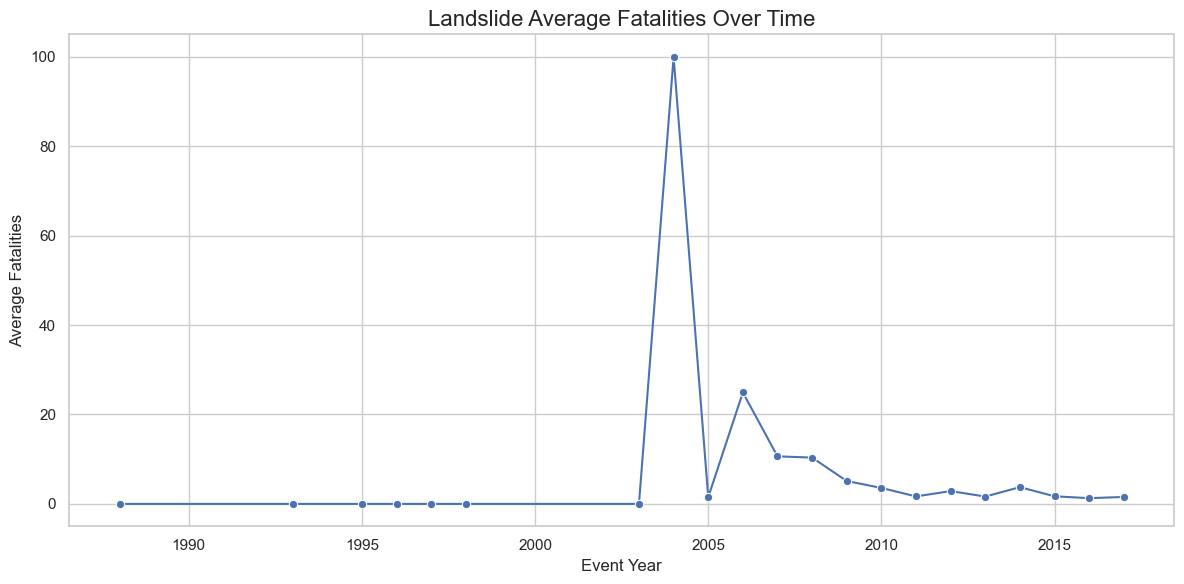

In [155]:
# filter out outlier fatalities
subset = filter_outliers(clean_landslides, "fatality_count", upper=4000)

# aggregate mean fatalities per year
yearly_avg = aggregate_mean(subset, "event_year", "fatality_count", new_col="ave_fatal")

# plot line graph
plot_line(
    yearly_avg, x="event_year", y="ave_fatal",
    title="Landslide Average Fatalities Over Time",
    xlabel="Event Year", ylabel="Average Fatalities"
)

The line chart shows the average number of fatalities from landslides over time (1988–2017).

A dramatic spike appears in 2004, where the average fatalities exceeded 100 deaths per event. This anomaly suggests one or more unusually severe landslide events during that year.

Following 2004, the average fatalities per event decline sharply and remain comparatively low, generally under 10 deaths per event from 2010 onward.

The trend indicates that while large-scale, high-fatality events do occur, they are rare outliers. Most landslide events in recent years have resulted in fewer fatalities per incident, reflecting either improved disaster response, better data recording, or a shift in the types of events being reported.

This visualization highlights the variability in landslide severity over time, complementing the earlier fatality count analysis by showing that extreme, high-fatality events are exceptions rather than the norm.

In [156]:
def aggregate_max(df, group_col, value_col, new_col="max_value", sort=True):
    """
    Group by a column and compute the maximum of another column.
    
    """
    out = df.groupby(group_col, dropna=False)[value_col].max().reset_index()
    out.rename(columns={value_col: new_col}, inplace=True)
    if sort:
        out = out.sort_values(group_col)
    return out

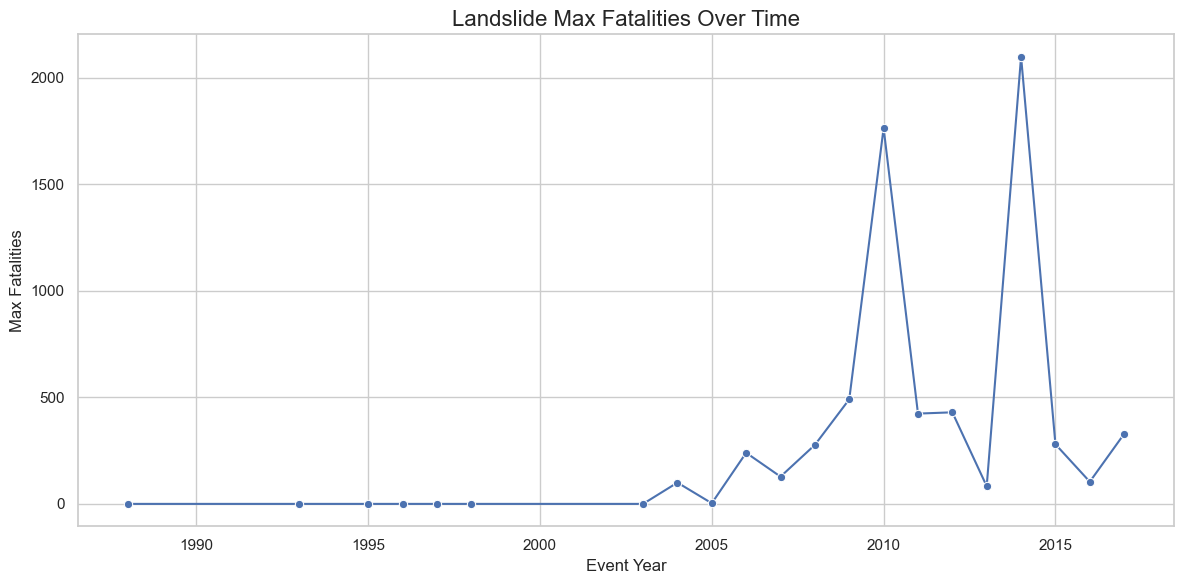

In [157]:
# filter out outlier fatalities
subset = filter_outliers(clean_landslides, "fatality_count", upper=4000)

# aggregate max fatalities per year
yearly_max = aggregate_max(subset, "event_year", "fatality_count", new_col="max_fatal")

# plot line graph
plot_line(
    yearly_max, x="event_year", y="max_fatal",
    title="Landslide Max Fatalities Over Time",
    xlabel="Event Year", ylabel="Max Fatalities"
)

The chart highlights the largest single-event fatalities per year.

From 1988 through the early 2000s, maximum annual fatalities remained very low. Beginning in the mid-2000s, individual catastrophic events became more apparent, with extreme spikes in 2010 and 2014, each exceeding 1,500–2,000 deaths from a single landslide. After 2014, the maximum yearly fatalities decreased, but occasional severe events continued to appear.

Overall, this visualization demonstrates how rare but extreme disasters drive much of the human toll from landslides, underscoring their unpredictable and devastating nature.

In [158]:
over_1500_count = clean_landslides[clean_landslides['fatality_count'] > 1500].shape[0]
print("Number of landslides with fatality count over 1500:", over_1500_count)

Number of landslides with fatality count over 1500: 3


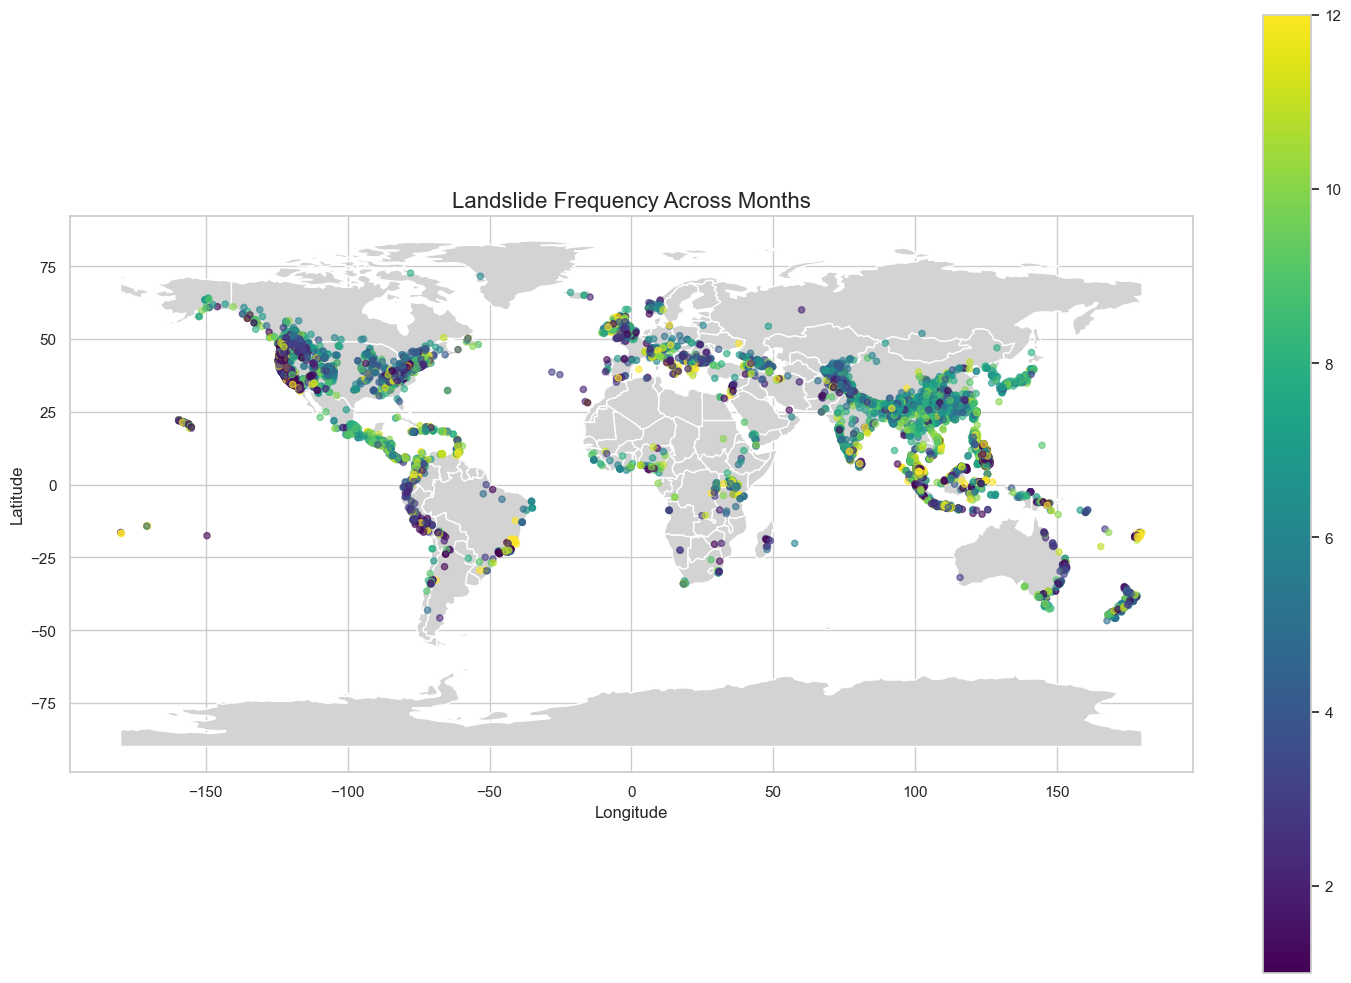

In [159]:
geo_df = to_geodataframe(clean_landslides)
plot_world_events(
    geo_df,
    column="event_month",
    cmap="viridis",
    title="Landslide Frequency Across Months",
    markersize=20
)

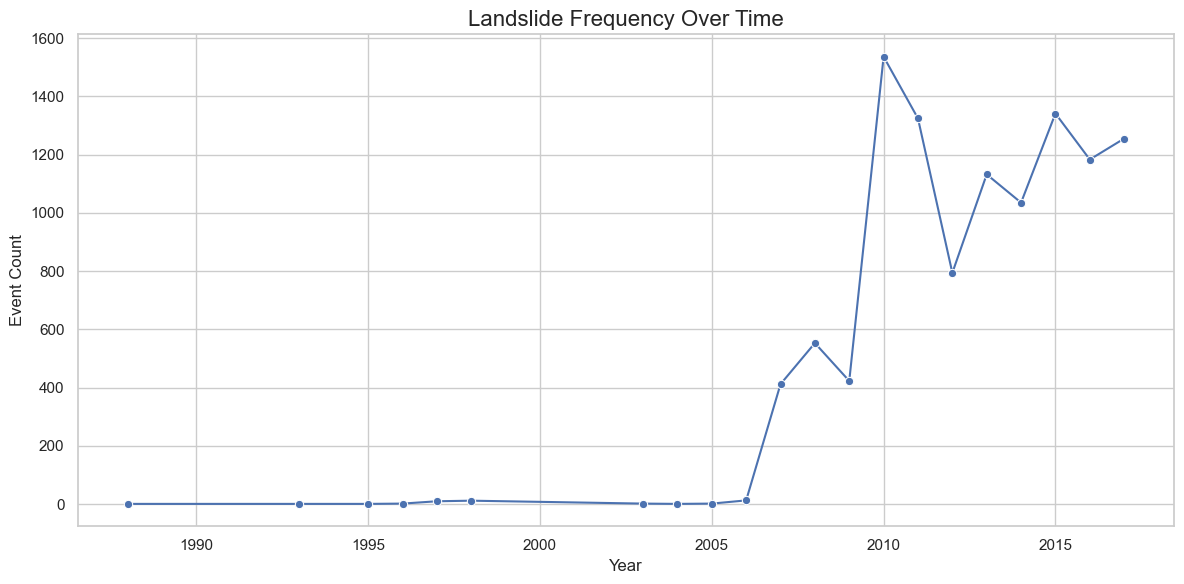

In [160]:
# aggregate counts per year
year_subset = aggregate_counts(clean_landslides, "event_year").rename(columns={"count": "event_count"})

# plot frequency over time
plot_line(
    year_subset, x="event_year", y="event_count",
    title="Landslide Frequency Over Time",
    xlabel="Year", ylabel="Event Count"
)

The two visuals together highlight how landslide frequency varies across both time and seasonality.

The **global map** by months adds a seasonal and geographic layer. Events cluster heavily in South Asia, Southeast Asia, and Central America, with color variation indicating concentration in the rainy months (typically mid-year for monsoon regions and late-year for storm-prone areas).

The **line chart** of frequency over time shows that reported landslides were sparse before the mid-2000s, followed by a sharp increase, peaking around 2010. Afterward, annual counts remain consistently high, reflecting both a true rise in events and improved reporting.

Together, these plots provide strong evidence toward the hypothesis question:
“In which regions and seasons do landslides occur most often?”

In [161]:
# Filter years with more than 249 landslides
yrs_250plus = year_subset[year_subset['event_count'] > 249]

# Find the first year where this jump occurred
min_year = yrs_250plus['event_year'].min()
print("First year with > 249 landslides:", min_year)

First year with > 249 landslides: 2007


In [162]:
sum_slides = clean_landslides.groupby('event_year').size().reset_index(name='count')

In [163]:
sum_2006 = sum_slides[sum_slides['event_year'] == 2006]['count'].sum()
print(f"Number of landslide events in 2006: {sum_2006}")

Number of landslide events in 2006: 13


In [164]:
sum_2007 = sum_slides[sum_slides['event_year'] == 2007]['count'].sum()
print(f"Number of landslide events in 2007: {sum_2007}")

Number of landslide events in 2007: 412


In [165]:
def aggregate_nunique(df, group_col, value_col, new_col="unique_count", sort=True):
    """
    Group by a column and count unique values of another column.
    
    """
    out = df.groupby(group_col, dropna=False)[value_col].nunique().reset_index()
    out.rename(columns={value_col: new_col}, inplace=True)
    if sort:
        out = out.sort_values(group_col)
    return out

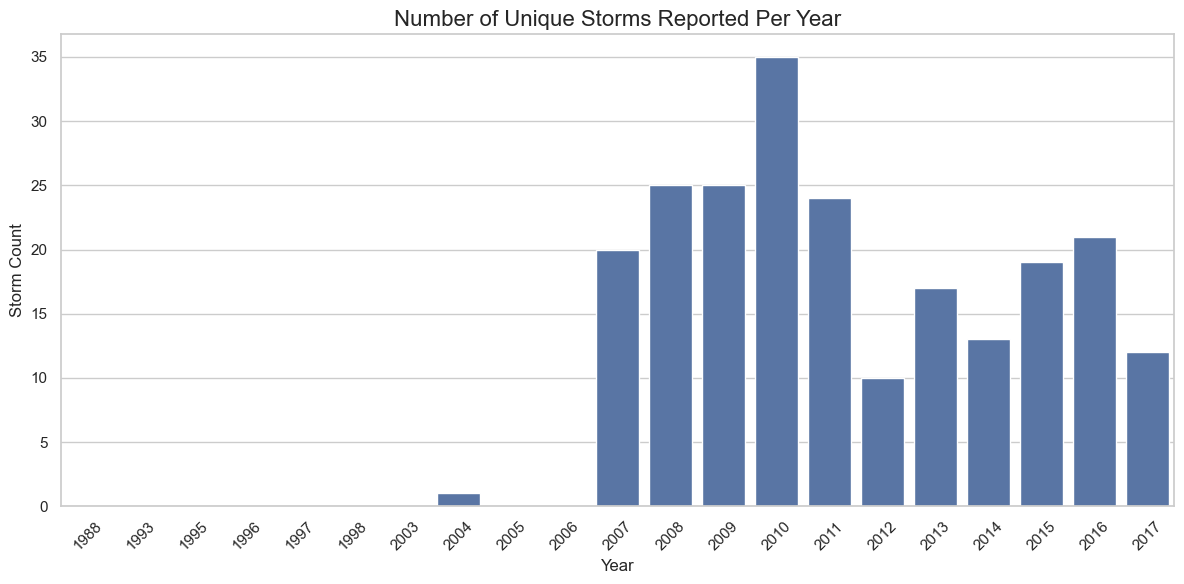

In [166]:
# aggregate unique storms per year
storm_freq = aggregate_nunique(clean_landslides, "event_year", "storm_name", new_col="unique_storms")

# plot
plot_bar(
    storm_freq, x="event_year", y="unique_storms",
    title="Number of Unique Storms Reported Per Year",
    xlabel="Year", ylabel="Storm Count", rotation=45, figsize=(12,6)
)

The bar chart shows the number of unique storms reported per year (1988–2017).

Storm reports are virtually absent before 2004, reflecting either limited data collection or underreporting. From 2007 to 2011, storm counts increase sharply, peaking in 2010 with 35 unique storms — aligning with the same year that landslide frequency also reached its highest levels. After 2010, storm counts fluctuate but remain consistently higher than in the early years, with secondary peaks in 2015–2016.

This trend reinforces the observation that storm activity and landslide occurrence are closely linked, with the storm-heavy years aligning with higher landslide frequencies and fatalities.

In [167]:
def min_max_normalize(series):
    """
    Normalize a pandas Series to [0, 1] using min-max scaling.
    
    """
    return (series - series.min()) / (series.max() - series.min())

def plot_multiple_lines(data_dict, title, xlabel="X", ylabel="Y", figsize=(10,6)):
    """
    Plot multiple lines on the same chart.
    
    """
    plt.figure(figsize=figsize)
    for label, (x, y, style) in data_dict.items():
        plt.plot(x, y, style, label=label, marker="o")
    plt.title(title, fontsize=16)
    plt.xlabel(xlabel); plt.ylabel(ylabel)
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

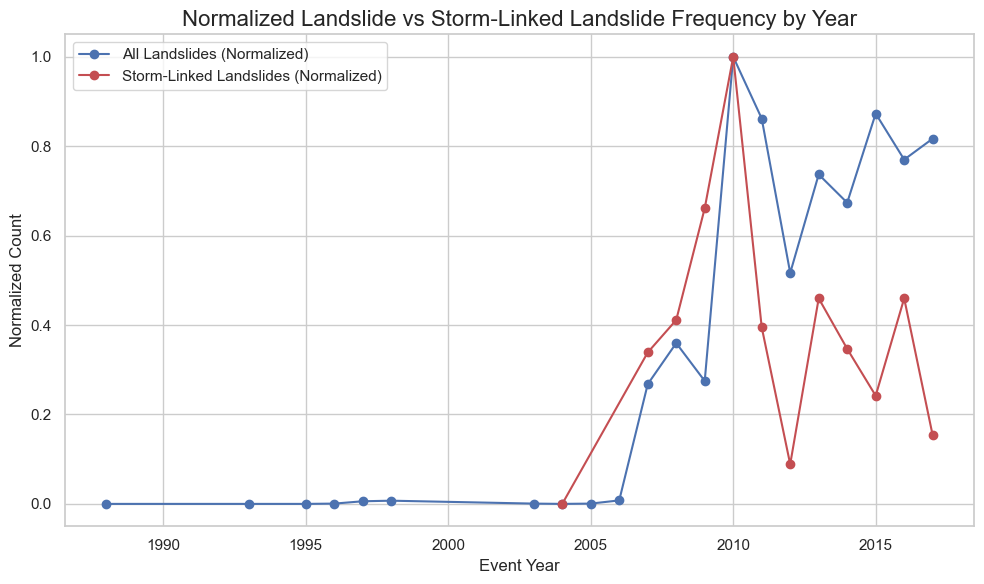

In [168]:
# Count totals
sum_slides = aggregate_counts(clean_landslides, "event_year").rename(columns={"count": "total_count"})

# Count storms only
storm_slides = filter_nonempty(clean_landslides, "storm_name")
sum_storms = aggregate_counts(storm_slides, "event_year").rename(columns={"count": "storm_count"})

# Normalize
sum_slides["norm"] = min_max_normalize(sum_slides["total_count"])
sum_storms["norm"] = min_max_normalize(sum_storms["storm_count"])

# Plot both
plot_multiple_lines(
    {
        "All Landslides (Normalized)": (sum_slides["event_year"], sum_slides["norm"], "b-"),
        "Storm-Linked Landslides (Normalized)": (sum_storms["event_year"], sum_storms["norm"], "r-"),
    },
    title="Normalized Landslide vs Storm-Linked Landslide Frequency by Year",
    xlabel="Event Year", ylabel="Normalized Count"
)

The line chart compares all reported landslides (blue) with storm-linked landslides (red), normalized for consistency across years.

Both series rise sharply in the late 2000s, with a clear shared peak in 2010, confirming that storms were a significant driver of the overall surge in landslide activity during that year. After 2010, the two lines diverge - All landslides remain consistently high, though with some year-to-year variation. Storm-linked landslides decline more steeply, showing greater volatility from year to year. This suggests that while storms are a critical trigger, they represent only part of the broader landslide activity, which is also influenced by other natural and man-made factors.

Together with the earlier storm count chart, this supports the hypothesis that rainfall and storm activity are closely tied to landslide frequency, but not the sole explanation for long-term trends.

In [169]:
# Showing the values for the sizes of landslides that are in the dataframe
print(clean_landslides['landslide_size'].unique())

['large' 'small' 'medium' 'unknown' 'very_large' nan 'catastrophic']


In [170]:
# Map size categories to numeric values
size_map = {
    "catastrophic": 5,
    "very_large": 4,
    "large": 3,
    "medium": 2,
    "small": 1
}

In [171]:
# Create numeric_size column (NaN if unknown or missing)
clean_landslides['numeric_size'] = clean_landslides['landslide_size'].map(size_map).astype(float)

# Group and count by landslide_size
sum_size = clean_landslides.groupby('landslide_size').size().reset_index(name='count')

print(sum_size)

  landslide_size  count
0   catastrophic      3
1          large    750
2         medium   6551
3          small   2767
4        unknown    851
5     very_large    102


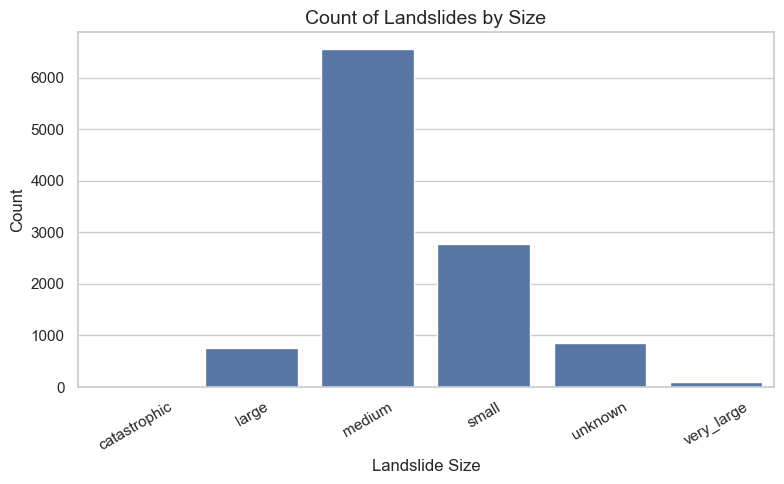

In [172]:
plt.figure(figsize=(8,5))
sns.barplot(x="landslide_size", y="count", data=sum_size)

plt.xlabel("Landslide Size", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Count of Landslides by Size", fontsize=14)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

The bar chart shows the distribution of landslide events by size.

Medium-sized landslides are the most common, with over 6,000 recorded events. Small landslides are the next most frequent, followed by a smaller number of large and unknown-sized events. Very large and catastrophic events are rare in comparison, though they often carry greater human and environmental impacts when they do occur.

This highlights that while most landslides are moderate in scale, the largest events, though less frequent, remain the most dangerous.

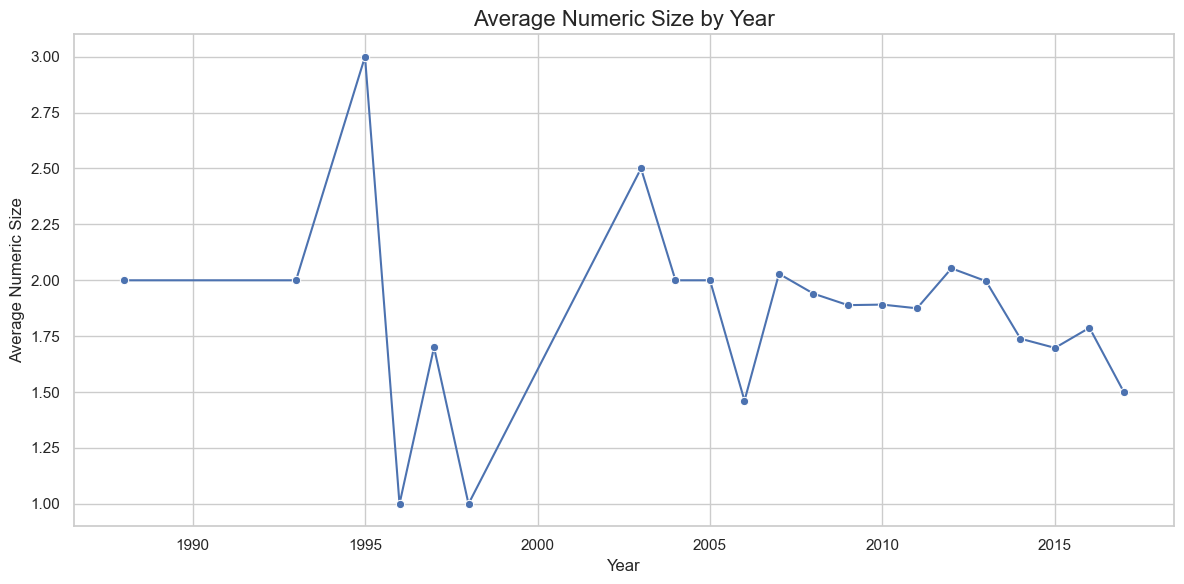

In [173]:
# Filter rows with numeric_size not NaN and make a copy
sized_slides = clean_landslides[clean_landslides['numeric_size'].notna()].copy()

# Ensure event_date is datetime
sized_slides['event_date'] = pd.to_datetime(sized_slides['event_date'], errors='coerce')

# Sort by date so the line connects in chronological order
sized_slides = sized_slides.sort_values('event_date')

# Aggregate numeric_size by year
yearly_size = (
    sized_slides.groupby(sized_slides["event_date"].dt.year)["numeric_size"]
    .mean()
    .reset_index()
)

# Plot with reusable helper
plot_line(
    yearly_size,
    x="event_date", y="numeric_size",
    title="Average Numeric Size by Year",
    xlabel="Year", ylabel="Average Numeric Size"
)

The line chart shows the average numeric size of landslides by year (1988–2017).

The early years (pre-2000) show considerable variability, likely due to limited reporting and smaller sample sizes. Some years appear as outliers, with unusually high or low averages. From the mid-2000s onward, the trend stabilizes, with most years averaging between 1.5 and 2.0 on the numeric size scale. A slight downward trend is visible in the 2010s, suggesting that while more landslides were reported in this period, they were often smaller in size on average compared to earlier years.

This visualization highlights that the dataset is dominated by small to medium landslides, with catastrophic events being relatively rare, though still impactful when they occur.

In [174]:
# gazeteer_distance indicates the distance from the event to the nearest populated place
na_count = clean_landslides['gazeteer_distance'].isna().sum()
print(f"Number of NA's in gazeteer_distance column: {na_count}")

Number of NA's in gazeteer_distance column: 1562


In [175]:
# Filter for missing gazeteer_distance
unreported_slides = clean_landslides[clean_landslides['gazeteer_distance'].isna()].copy()

# Get date range
date_range = (unreported_slides['event_date'].min(), unreported_slides['event_date'].max())
print(f"Unreported gazeteer_distance landslides date range: {date_range[0].strftime('%B %d, %Y')} to {date_range[1].strftime('%B %d, %Y')}")

Unreported gazeteer_distance landslides date range: November 20, 2007 to September 28, 2017


In [176]:
# Filter for reported slides
reported_slides = clean_landslides[clean_landslides['gazeteer_distance'].notna()].copy()

# Count how many
reported_count = reported_slides['gazeteer_distance'].count()
print(f"Number of slides with reported gazeteer_distance: {reported_count}")

Number of slides with reported gazeteer_distance: 9471


In [177]:
# Get the range (min and max) of gazeteer_distance for reported slides
distance_range = (
    reported_slides['gazeteer_distance'].min(),
    reported_slides['gazeteer_distance'].max()
)
print(f"Gazeteer distance ranges from {distance_range[0]:.2f} km to {distance_range[1]:.2f} km")

Gazeteer distance ranges from 0.00 km to 215.45 km


In [178]:
# Make sure event_date is datetime
reported_slides['event_date'] = pd.to_datetime(reported_slides['event_date'], errors='coerce')

# Get the min and max dates
date_range = (
    reported_slides['event_date'].min(),
    reported_slides['event_date'].max()
)
print(f"Earliest slide with reported gazeteer_distance: {date_range[0].date()}")
print(f"Latest slide with reported gazeteer_distance: {date_range[1].date()}")

Earliest slide with reported gazeteer_distance: 1988-11-07
Latest slide with reported gazeteer_distance: 2016-10-25


In [179]:
unique_sources_count = clean_landslides['source_name'].nunique(dropna=False)
print(f"Number of unique reported sources: {unique_sources_count}")

Number of unique reported sources: 3918


In [180]:
unique_sources_count = reported_slides['source_name'].nunique()
print(f"Number of unique sources (with reported gazeteer_distance): {unique_sources_count}")

Number of unique sources (with reported gazeteer_distance): 3334


In [181]:
# Group and summarize
sources_df = (
    clean_landslides
    .groupby('source_name')
    .agg(
        total_landslides=('source_name', 'size'),  # counts rows per source_name
        first_event_date=('event_date', 'min'),
        last_event_date=('event_date', 'max')
    )
    .reset_index()
    .sort_values('total_landslides', ascending=False)
)


In [182]:
average_slides = sources_df['total_landslides'].mean()
print(f"Average number of landslides per source: {average_slides:.2f}")

Average number of landslides per source: 2.82


In [183]:
# Display the first 10 sources and their reported landslide counts
sources_df.head(10)

,source_name,total_landslides,first_event_date,last_event_date
1425,Oregon DOT,768,2011-01-06,2016-05-16
2943,maps.google.com,104,2010-04-06,2010-04-06
3388,thehimalayantimes,75,2008-08-26,2012-09-18
3071,news.xinhuanet,74,2008-01-13,2012-07-07
3084,newsinfo.inquirer,71,2008-01-06,2012-12-27
3393,thejakartapost,59,2008-10-18,2015-01-18
2753,ibnlive.in,57,2011-03-01,2012-08-18
2002,Times of India,47,2007-12-16,2017-09-02
1854,The Jakarta Post,46,2009-11-21,2017-04-09
1841,The Himalayan Times,43,2010-09-17,2017-07-10


In [184]:
# Make sure first_event_date is datetime
sources_df['first_event_date'] = pd.to_datetime(sources_df['first_event_date'], errors='coerce')

# Count how many are before 2007-01-01
count_before_2007 = (sources_df['first_event_date'] < pd.Timestamp("2007-01-01")).sum()
print(f"Sources with first report before 2007: {count_before_2007}")


Sources with first report before 2007: 12


In [185]:
# Find duplicates based on specific columns
dup_mask = clean_landslides.duplicated(subset=['event_date', 'event_time', 'longitude', 'latitude']) | \
           clean_landslides.duplicated(subset=['event_date', 'event_time', 'longitude', 'latitude'], keep='last')

dup_landslides = clean_landslides[dup_mask].copy()

# Count source_name values in duplicates
duplicate_count = dup_landslides['source_name'].count()
print(f"Duplicate events found (based on date, time, and location): {duplicate_count}")

Duplicate events found (based on date, time, and location): 64


In [186]:
# Sort duplicates by event_date
sorted_dups = dup_landslides.sort_values('event_date')

# Show first 10 rows
print(sorted_dups[['event_date', 'event_time', 'longitude', 'latitude', 'source_name']].head(10))

      event_date event_time  longitude  latitude                  source_name
3853  2010-04-06   00:00:00   -43.1789  -22.8200              maps.google.com
1619  2010-04-06   00:00:00   -43.1789  -22.8200              maps.google.com
3308  2013-06-25   08:00:00    77.5947   10.9628  timesofindia.indiatimes.com
113   2013-06-25   08:00:00    77.5947   10.9628  timesofindia.indiatimes.com
114   2013-06-25   08:00:00    77.5947   10.9628  timesofindia.indiatimes.com
4406  2013-07-12   00:00:00    79.4633   29.3802            www.newsworms.com
4528  2013-07-12   00:00:00    79.4633   29.3802            www.newsworms.com
4445  2013-07-25   00:00:00    78.4800   30.8928     www.newindianexpress.com
8022  2013-07-25   00:00:00    78.4800   30.8928     www.newindianexpress.com
9049  2013-08-19   00:00:00   120.7617   16.7667              news.pia.gov.ph


In [187]:
# Filter for 2007 events
target2007 = clean_landslides[clean_landslides['event_year'] == 2007].copy()

# Count unique source_name values
unique_sources_2007 = target2007['source_name'].nunique()
print(f"Unique reporting sources in 2007: {unique_sources_2007}")

Unique reporting sources in 2007: 230


In [188]:
# Count unique sources per year
source_counts = (
    clean_landslides
    .groupby('event_year')['source_name']
    .nunique()
    .reset_index(name='unique_sources')
)

# Merge with sum_slides DataFrame 
combined_data = pd.merge(source_counts, sum_slides, on='event_year', how='inner')

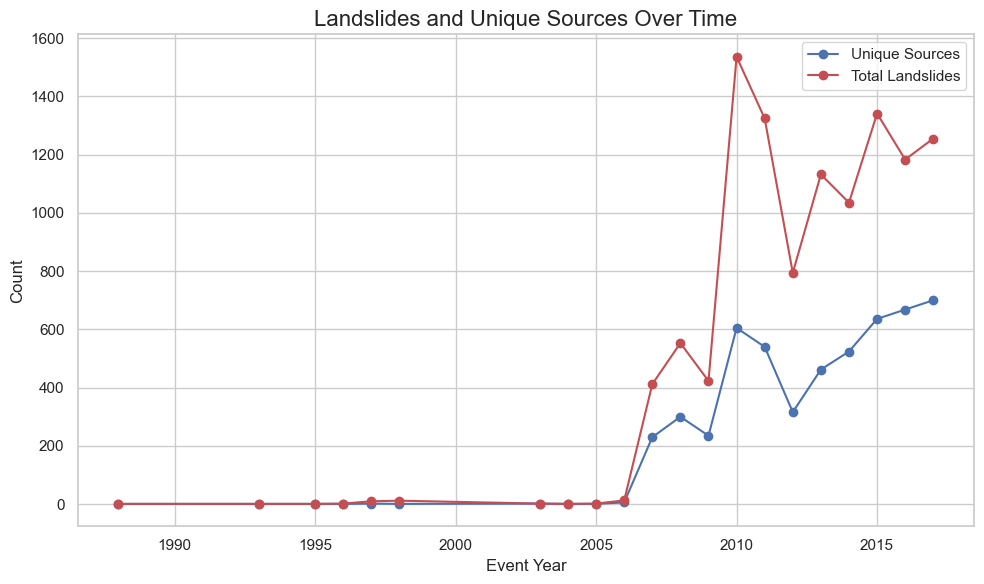

In [189]:
plot_multiple_lines(
    {
        "Unique Sources": (combined_data["event_year"], combined_data["unique_sources"], "b-"),
        "Total Landslides": (combined_data["event_year"], combined_data["total_count"], "r-"),
    },
    title="Landslides and Unique Sources Over Time",
    xlabel="Event Year", ylabel="Count"
)

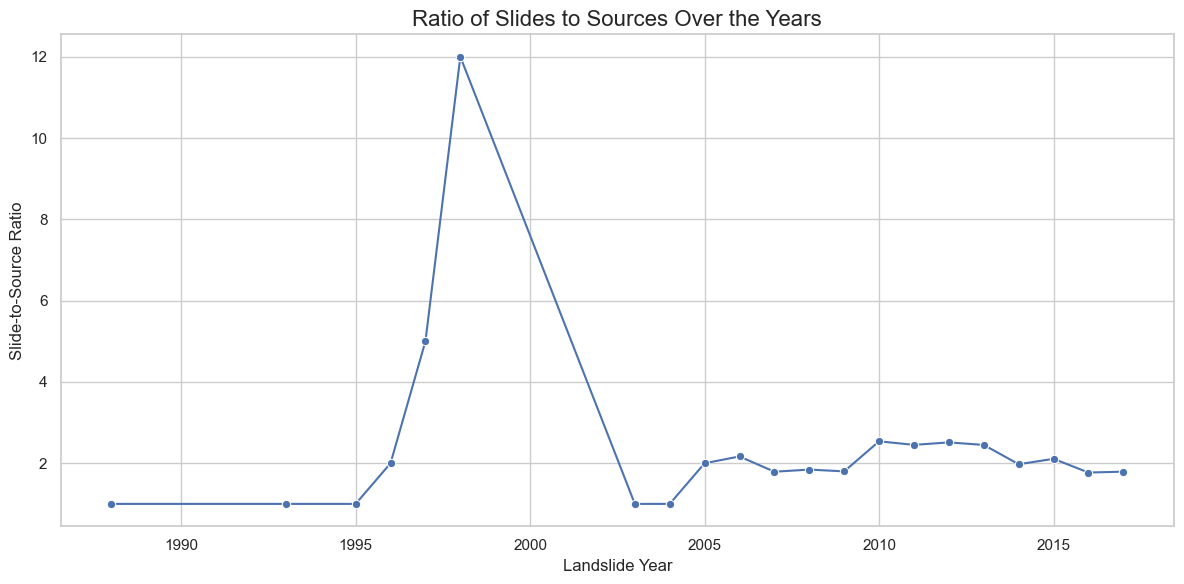

In [190]:
# 1) Build the ratio (guard against divide-by-zero just in case)
combined_data = combined_data.copy()
combined_data["slide_source_ratio"] = (
    combined_data["total_count"] / combined_data["unique_sources"].replace({0: pd.NA})
)

# 2) Sort by year so the line connects in order
combined_data = combined_data.sort_values("event_year")

# 3) Plot the ratio
plot_line(
    combined_data,
    x="event_year", y="slide_source_ratio",
    title="Ratio of Slides to Sources Over the Years",
    xlabel="Landslide Year", ylabel="Slide-to-Source Ratio"
)

The charts of landslide counts and reporting sources reveal two key dynamics. First, total reported landslides increased substantially after the mid-2000s, coinciding with a rise in the number of unique reporting sources. This expansion suggests both greater landslide activity and improved coverage.

When we normalize this relationship as a ratio of slides to sources, a sharp spike in the late 1990s becomes visible, likely reflecting a period when a small number of outlets accounted for most reporting. After 2005, the ratio stabilizes, indicating that landslide documentation has since become more distributed across a larger and more diverse set of contributors.

## SVM Classifications and Source Text Analysis

In [191]:
# Create binary storm_present column
clean_landslides = clean_landslides.copy()
clean_landslides["storm_present"] = clean_landslides["storm_name"].apply(
    lambda x: 0 if pd.isna(x) or x == "" else 1
)

# Build numeric-only DataFrame for modeling
numeric_data = clean_landslides[[
    "longitude", 
    "latitude", 
    "event_month", 
    "numeric_size", 
    "storm_present", 
    "fatality_count", 
    "injury_count"
]].copy()

In [192]:
# Split data
X = numeric_data.drop(columns=["storm_present"])
y = numeric_data["storm_present"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
# Check class balance in train and test sets
print("Train class distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Train class distribution:
storm_present
0    0.947689
1    0.052311
Name: proportion, dtype: float64

Test class distribution:
storm_present
0    0.947734
1    0.052266
Name: proportion, dtype: float64


The training and test sets both show a highly imbalanced class distribution, with only about 5% of events linked to storms. This imbalance is important to keep in mind, as it makes prediction more challenging and requires careful model evaluation.  

In [193]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [194]:
# Reusable evaluation function
def run_classifier(model, X_train, X_test, y_train, y_test, name="Model", labels=None):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if labels is None:
        # default to sorted unique labels from y_test
        labels = list(np.unique(y_test))

    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, digits=3, labels=labels, target_names=[str(l) for l in labels]))

    cm = confusion_matrix(y_test, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(cmap=plt.cm.viridis, values_format="d")
    plt.title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return y_pred, model


=== Storm Presence Prediction ===
              precision    recall  f1-score   support

           0      0.975     0.986     0.980      3137
           1      0.679     0.538     0.600       173

    accuracy                          0.963      3310
   macro avg      0.827     0.762     0.790      3310
weighted avg      0.959     0.963     0.960      3310



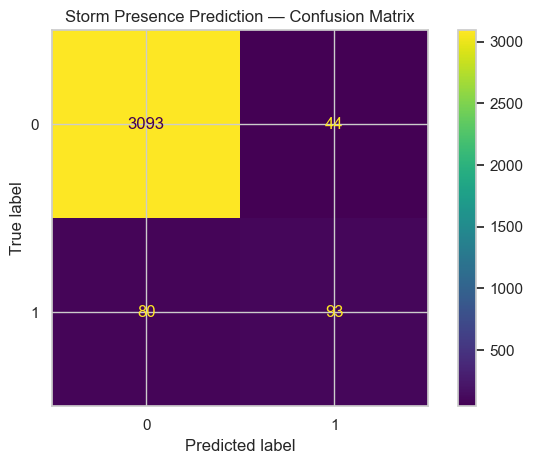

In [195]:
# Using HistGradientBoosting as it handles imbalanced data well and can capture non-linear relationships
hgb = HistGradientBoostingClassifier(random_state=42)
y_pred_hgb, hgb_model = run_classifier(hgb, X_train, X_test, y_train, y_test, name="Storm Presence Prediction")

The HistGradientBoosting model achieves strong overall accuracy (96%), driven largely by excellent performance on the majority class (non-storm events). Precision and recall for class 0 are both above 97%, meaning the model is highly reliable at identifying landslides not linked to storms.

However, performance drops significantly for class 1 (storm-linked events), with recall at just 54% and an F1-score of 0.60. This indicates the model struggles to correctly capture storm-related landslides, likely due to the strong class imbalance in the dataset (only ~5% storm events). The confusion matrix confirms this trend, showing a large number of true negatives correctly classified but many false negatives for storm-linked cases.

In [196]:
# Filter out outliers
numeric_data_no_outliers = numeric_data[numeric_data["fatality_count"] < 1750].copy()
print(f"Rows after filtering: {numeric_data_no_outliers.shape[0]} (out of {numeric_data.shape[0]})")

Rows after filtering: 9645 (out of 11033)


In [197]:
# Create fatality_severity bins
numeric_data_no_outliers["fatality_severity"] = np.where(
    numeric_data_no_outliers["fatality_count"] == 0, 
    "none",
    pd.cut(
        numeric_data_no_outliers["fatality_count"],
        bins=[0, 100, 500, np.inf],      # 1–99, 100–499, 500+
        labels=["low", "medium", "high"],
        right=False
    ).astype(str)
)

print(numeric_data_no_outliers["fatality_severity"].value_counts())

fatality_severity
none      7206
low       2409
medium      30
Name: count, dtype: int64


In [198]:
# Define X (predictors) and y (target)
X = numeric_data_no_outliers.drop(columns=["fatality_count", "fatality_severity"])
y = numeric_data_no_outliers["fatality_severity"]

In [199]:
# Build pipeline with scaling + SVM
svm_model = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),   # replaces NaNs with column mean
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", class_weight="balanced"))  # RBF kernel
])


=== SVM (Fatality Severity) ===
              precision    recall  f1-score   support

         low      0.432     0.880     0.580      1445
      medium      0.012     0.167     0.023        18
        none      0.975     0.587     0.733      4324

    accuracy                          0.659      5787
   macro avg      0.473     0.544     0.445      5787
weighted avg      0.836     0.659     0.692      5787



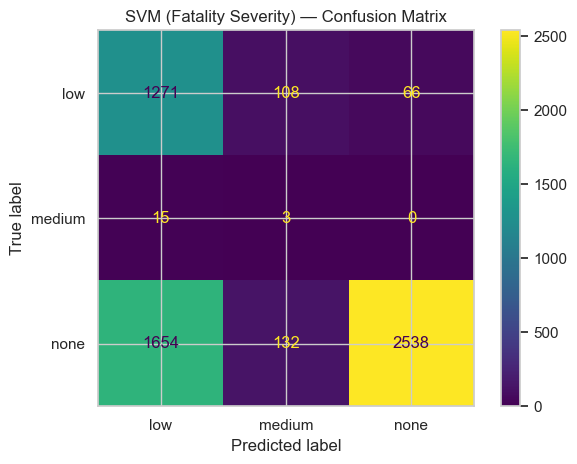

In [200]:
# Fatality severity split
X_train_sev, X_test_sev, y_train_sev, y_test_sev = train_test_split(
    X, y, train_size=0.4, random_state=123, stratify=y
)

# evaluate the SVM on severity
y_pred_svm, svm_fitted = run_classifier(
    svm_model, X_train_sev, X_test_sev, y_train_sev, y_test_sev,
    name="SVM (Fatality Severity)"
)

The SVM model for predicting fatality severity demonstrates strong performance in detecting events with no fatalities (“none”), though recall is lower, suggesting many non-fatal cases are mislabeled. For “low” fatality events, the model captures a reasonable number correctly but still shows notable misclassification. The “medium” category is almost entirely missed, reflecting its rarity in the dataset and the model’s difficulty in learning from so few examples.

These results highlight that the model is heavily influenced by class imbalance, performing best on the majority class (“none”) while struggling to recognize less frequent fatality categories.

In [201]:
# Text column (drop NaNs)
docs = clean_landslides["event_description"].dropna().astype(str).tolist()

In [202]:
# Build a stemmer + stopwords set
stemmer = SnowballStemmer("english")
stop = set(stopwords.words("english"))
token_pattern = re.compile(r"[A-Za-z]+")

In [203]:
def analyzer(doc):
    tokens = token_pattern.findall(doc.lower())
    stemmed = [stemmer.stem(t) for t in tokens]
    return [t for t in stemmed if t not in stop]

In [204]:
# CountVectorizer to create a Document-Term Matrix
vectorizer = CountVectorizer(analyzer=analyzer, min_df=2)
X = vectorizer.fit_transform(docs)

In [205]:
# Extract vocabulary terms and their overall frequencies across the corpus
terms = np.array(vectorizer.get_feature_names_out())
term_freq = np.asarray(X.sum(axis=0)).ravel()

In [206]:
# Show the dimensions of the document-term matrix (rows = documents, columns = terms)
print("DTM shape:", X.shape)  # (n_docs, n_terms)
# Display the first 10 vocabulary terms for a quick check of extracted features
print("First 10 terms:", terms[:10])

DTM shape: (10171, 11209)
First 10 terms: ['aa' 'aaj' 'aalo' 'aaron' 'ab' 'ababa' 'abad' 'abancay' 'abandon' 'abang']


In [207]:
# Create a dataframe of terms with their frequencies, sorted to show the most common words
top = (
    pd.DataFrame({"term": terms, "freq": term_freq})
    .sort_values("freq", ascending=False)
    .reset_index(drop=True)
)
top.head(20) # display the top 20 most frequent terms

,term,freq
0,landslid,10133
1,road,6752
2,said,5705
3,rain,4917
4,heavi,3240
5,area,3131
6,highway,2965
7,mudslid,2827
8,peopl,2644
9,caus,2565


The top terms in the dataset include “landslide,” “road,” “rain,” and “mudslide,” reflecting common themes in reports such as weather conditions and infrastructure impacts. These frequent words provide a quick snapshot of the main factors linked to landslide events.

In [208]:
# Create a dictionary mapping each term to its frequency
freq_dict = dict(zip(terms, term_freq))

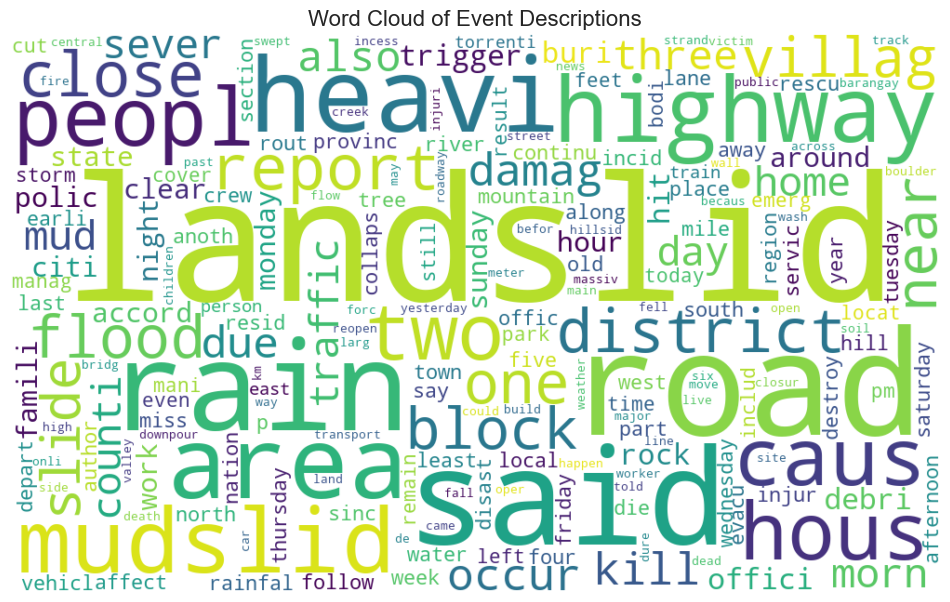

In [209]:
# Generate the word cloud
wc = WordCloud(
    width=1000, height=600,
    background_color="white",
    colormap="viridis"
).generate_from_frequencies(freq_dict)
# Plot it
plt.figure(figsize=(12, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Event Descriptions", fontsize=16)
plt.show()

count    10171.000000
mean        -0.365086
std          0.443846
min         -0.996300
25%         -0.765000
50%         -0.401900
75%          0.000000
max          0.977400
Name: sentiment, dtype: float64


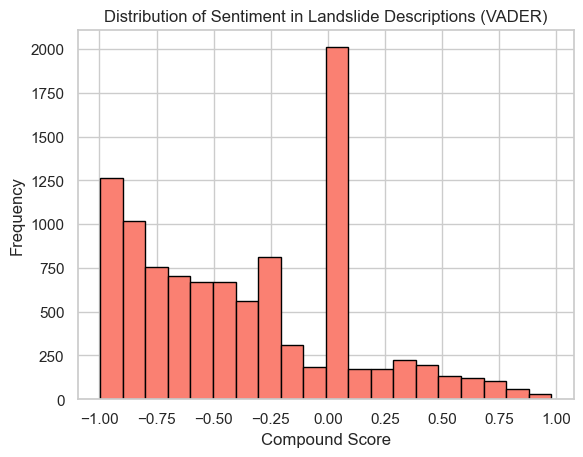

In [210]:
# Evaluating sentiment with VADER
sia = SentimentIntensityAnalyzer()
sentiments = [sia.polarity_scores(doc)["compound"] for doc in docs]

sentiment_df = pd.DataFrame({"doc": docs, "sentiment": sentiments})
print(sentiment_df["sentiment"].describe())

plt.hist(sentiment_df["sentiment"], bins=20, color="salmon", edgecolor="black")
plt.title("Distribution of Sentiment in Landslide Descriptions (VADER)")
plt.xlabel("Compound Score")
plt.ylabel("Frequency")
plt.show()

The **word cloud** highlights the most common terms in landslide event descriptions, with words such as “landslide,” “road,” “rain,” “mudslide,” and “highway” dominating. These terms emphasize the strong connection between landslide events and both environmental triggers (e.g., heavy rain, flooding, debris) and human impacts (e.g., blocked roads, damaged houses, and affected villages).

The **VADER sentiment distribution** further shows that the majority of landslide-related descriptions lean negative, with scores clustering below zero. This is expected, as these reports often document destruction, casualties, and disruption. While some neutral or slightly positive terms appear in the text, the overall sentiment skews negative, reflecting the serious and adverse nature of landslide events.

Together, these analyses provide context for how landslides are reported; the language used in descriptions conveys both the physical drivers and the human consequences, while sentiment scoring quantifies the overall tone of these narratives.

## Fatalities and Trigger Insights

In [211]:
# Summarize fatalities and population stats grouped by landslide category
summary_populationFatalities = (
    clean_landslides
    .groupby("landslide_category")
    .agg(
        fatalities_count=("fatality_count", "count"),
        pop_mean=("admin_division_population", "mean"),
        pop_max=("admin_division_population", "max")
    )
    .reset_index()
    .round(2)
)

print("Summary of fatalities and population by landslide category:")
display(summary_populationFatalities)

Summary of fatalities and population by landslide category:


,landslide_category,fatalities_count,pop_mean,pop_max
0,complex,167,153384.15,7871900.0
1,creep,5,12980.00,50253.0
2,debris_flow,176,198931.80,10349312.0
3,earth_flow,7,12096.67,27978.0
4,lahar,4,14482.43,64234.0
5,landslide,6610,166824.97,12691836.0
6,mudslide,1868,147955.00,12691836.0
7,other,67,175757.80,3920222.0
8,riverbank_collapse,33,63198.12,850848.0
9,rock_fall,647,78612.16,11624219.0


While the earlier chart highlighted which categories account for the most fatalities overall, this table adds context by showing the average and maximum population sizes of the administrative divisions where each event occurred. For instance, broad “landslide” and “mudslide” events not only account for the highest fatality totals but also tend to occur in more densely populated areas. In contrast, categories like rock falls or avalanches typically affect smaller populations. 

In [212]:
# Exclude NA fatalities and sort by date
datedSubset = clean_landslides.dropna(subset=["fatality_count"]).sort_values("event_date")

# Make sure event_date is datetime
datedSubset["event_date"] = pd.to_datetime(datedSubset["event_date"], errors="coerce")

# High fatality subset
HighFatalSubset = datedSubset[datedSubset["fatality_count"] > 500].copy()

# Extract year
HighFatalSubset["year"] = HighFatalSubset["event_date"].dt.year

HighFatalYear = (
    HighFatalSubset
    .groupby(["year", "landslide_category"], as_index=False)["fatality_count"]
    .sum()
    .rename(columns={"fatality_count": "total_fatalities"})
)

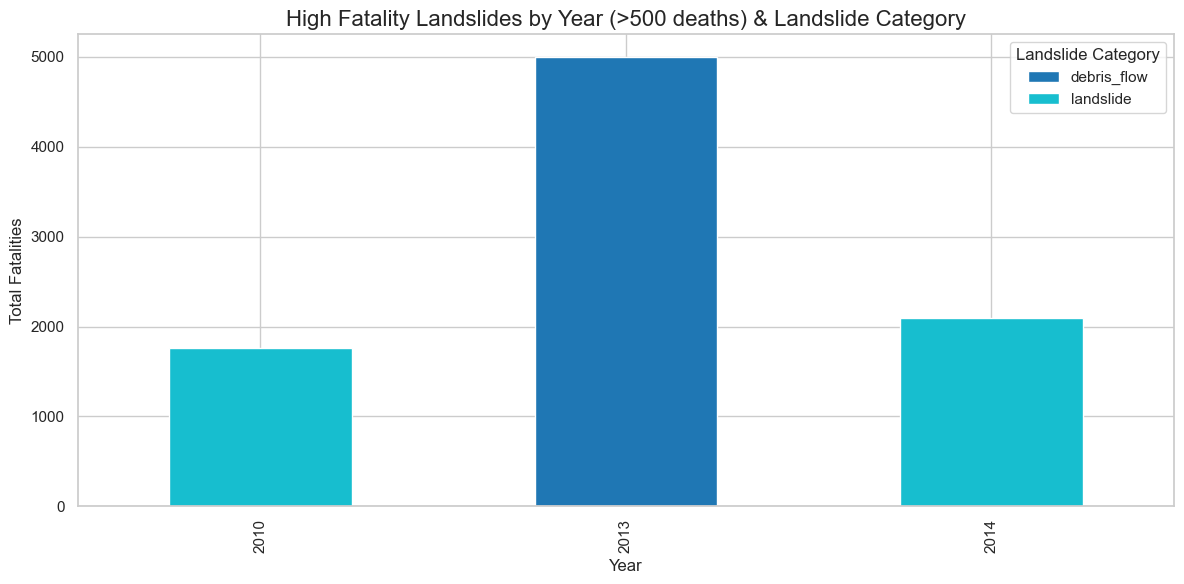

In [213]:
HighFatalPivot = HighFatalYear.pivot(
    index="year", columns="landslide_category", values="total_fatalities"
).fillna(0)

HighFatalPivot.plot(
    kind="bar", stacked=True, figsize=(12,6), colormap="tab10"
)

plt.title("High Fatality Landslides by Year (>500 deaths) & Landslide Category", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Fatalities", fontsize=12)
plt.legend(title="Landslide Category")
plt.tight_layout()
plt.show()

This chart shows landslide events with more than 500 deaths, broken down by year and category. The spike in 2013 reflects a particularly deadly debris flow, while 2010 and 2014 were dominated by generalized landslide events. These rare but catastrophic events highlight how certain years stand out in the dataset due to extreme disasters.

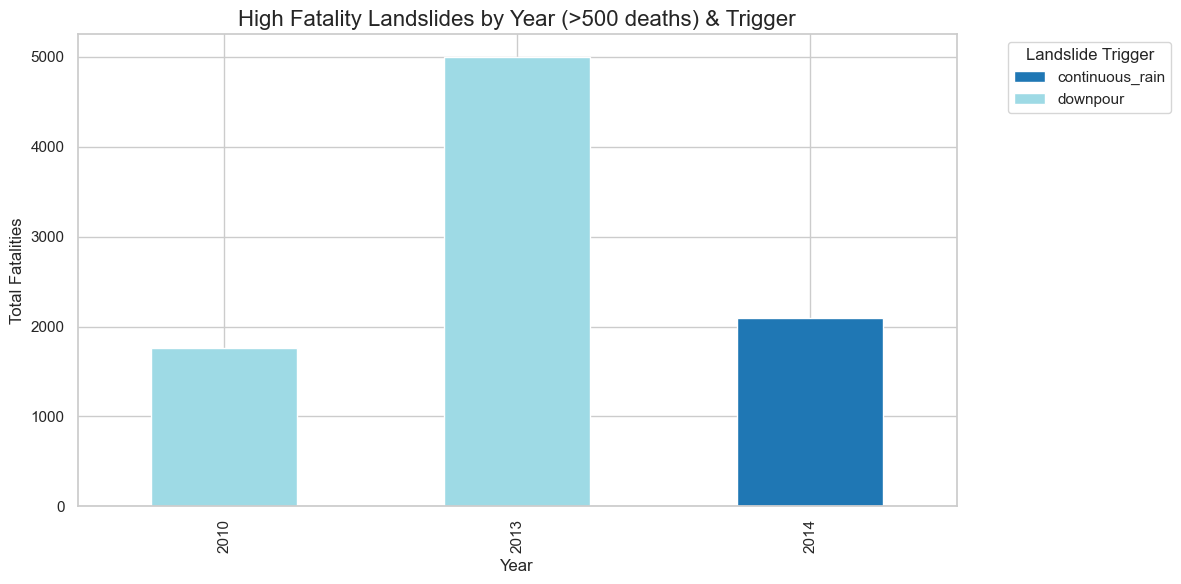

In [214]:
# Aggregate by year + trigger
HighFatalTrigger = (
    HighFatalSubset
    .groupby(["year", "landslide_trigger"], as_index=False)["fatality_count"]
    .sum()
    .rename(columns={"fatality_count": "total_fatalities"})
)

# Pivot for stacked bar
HighFatalTriggerPivot = HighFatalTrigger.pivot(
    index="year", columns="landslide_trigger", values="total_fatalities"
).fillna(0)

# Plot stacked bar
HighFatalTriggerPivot.plot(
    kind="bar", stacked=True, figsize=(12,6), colormap="tab20"
)

plt.title("High Fatality Landslides by Year (>500 deaths) & Trigger", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Fatalities", fontsize=12)
plt.legend(title="Landslide Trigger", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

This chart highlights the triggers associated with landslide events causing more than 500 deaths. The year 2013 shows the deadliest event, linked to a downpour, while 2014 was dominated by continuous rain. These results emphasize how extreme rainfall events—whether sudden or prolonged—are a primary driver behind the most catastrophic landslides in the dataset.

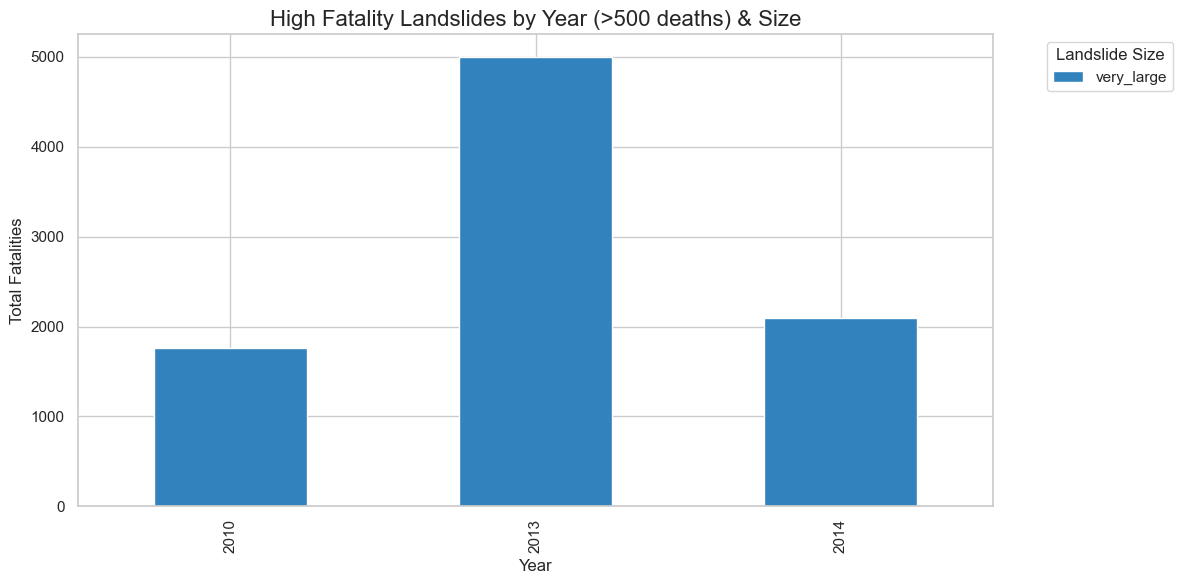

In [215]:
# Aggregate by year + size
HighFatalSize = (
    HighFatalSubset
    .groupby(["year", "landslide_size"], as_index=False)["fatality_count"]
    .sum()
    .rename(columns={"fatality_count": "total_fatalities"})
)

# Pivot for stacked bar
HighFatalSizePivot = HighFatalSize.pivot(
    index="year", columns="landslide_size", values="total_fatalities"
).fillna(0)

# Plot stacked bar
HighFatalSizePivot.plot(
    kind="bar", stacked=True, figsize=(12,6), colormap="tab20c"
)

plt.title("High Fatality Landslides by Year (>500 deaths) & Size", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Fatalities", fontsize=12)
plt.legend(title="Landslide Size", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

All high-fatality events (>500 deaths) fall into the "very large" size category, underscoring the scale of destruction caused by these rare but extreme landslides. 

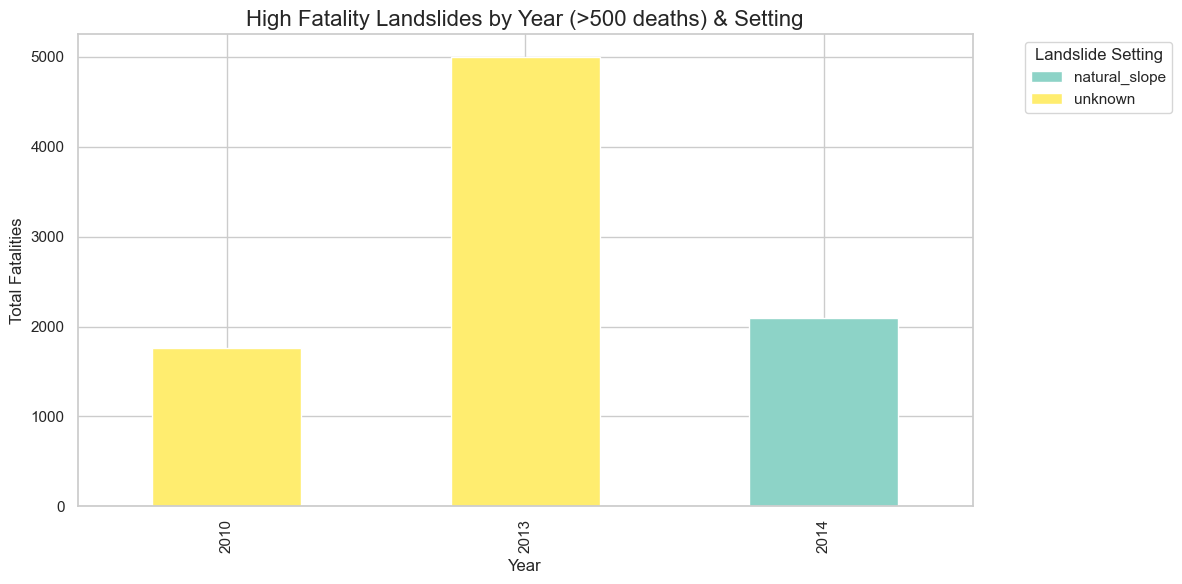

In [216]:
# Aggregate by year + setting
HighFatalSetting = (
    HighFatalSubset
    .groupby(["year", "landslide_setting"], as_index=False)["fatality_count"]
    .sum()
    .rename(columns={"fatality_count": "total_fatalities"})
)

# Pivot for stacked bar
HighFatalSettingPivot = HighFatalSetting.pivot(
    index="year", columns="landslide_setting", values="total_fatalities"
).fillna(0)

# Plot stacked bar
HighFatalSettingPivot.plot(
    kind="bar", stacked=True, figsize=(12,6), colormap="Set3"
)

plt.title("High Fatality Landslides by Year (>500 deaths) & Setting", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Fatalities", fontsize=12)
plt.legend(title="Landslide Setting", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

This chart shows that the deadliest landslides occurred on natural slopes, though some events remain categorized as unknown settings.  

In [217]:
# Show the events with fatalities > 4000
awful_fatal_subset = datedSubset[datedSubset["fatality_count"] > 4000].copy()

In [218]:
awful_fatal_subset[[
    "event_date",
    "country_name",
    "event_title",
    "landslide_category",
    "landslide_trigger",
    "landslide_size",
    "landslide_setting",
    "fatality_count"
]]

,event_date,country_name,event_title,landslide_category,landslide_trigger,landslide_size,landslide_setting,fatality_count
5694,2013-06-16,India,"Kedarnath (Hindu Shrine), Near Kedarnath Dome ...",debris_flow,downpour,very_large,unknown,5000.0


Filtering for events with more than 4,000 deaths highlights a single catastrophic landslide in India (2013), near the Kedarnath shrine. Classified as a very large debris flow triggered by a downpour, this disaster accounted for 5,000 fatalities, making it the deadliest event in the dataset.  

In [219]:
# taking a look at all the unique landslide triggers in the dataset
clean_landslides["landslide_trigger"].unique()

array(['rain', 'downpour', 'monsoon', 'tropical_cyclone', 'unknown',
       'continuous_rain', 'dam_embankment_collapse',
       'no_apparent_trigger', nan, 'other', 'leaking_pipe',
       'construction', 'snowfall_snowmelt', 'mining', 'flooding',
       'earthquake', 'freeze_thaw', 'volcano', 'vibration'], dtype=object)

In [220]:
MostFrequentTrigger = (
    clean_landslides.groupby("landslide_trigger")
    .size()                                 # counts per trigger
    .reset_index(name="count")
    .sort_values("count", ascending=False)  # order descending
    .head(1)                                # top row
)

trigger, count = MostFrequentTrigger.iloc[0]
print(f"Most frequent trigger: {trigger} ({count} occurrences)")

Most frequent trigger: downpour (4680 occurrences)


In [221]:
Landslides_downpours_country = (
    clean_landslides[
        (clean_landslides["landslide_trigger"] == "downpour") &
        (clean_landslides["country_name"].notna())
    ]
    .groupby("country_name")
    .size()  # counts
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(1)  # top row
)

country, count = Landslides_downpours_country.iloc[0]
print(f"Country with the most downpour-triggered landslides: {country} ({count} occurrences)")

Country with the most downpour-triggered landslides: United States (1098 occurrences)


In [222]:
# Count combinations of trigger + category
trigger_counts = (
    clean_landslides
    .dropna(subset=["landslide_trigger", "landslide_category"])
    .groupby(["landslide_trigger", "landslide_category"])
    .size()
    .reset_index(name="count")
)

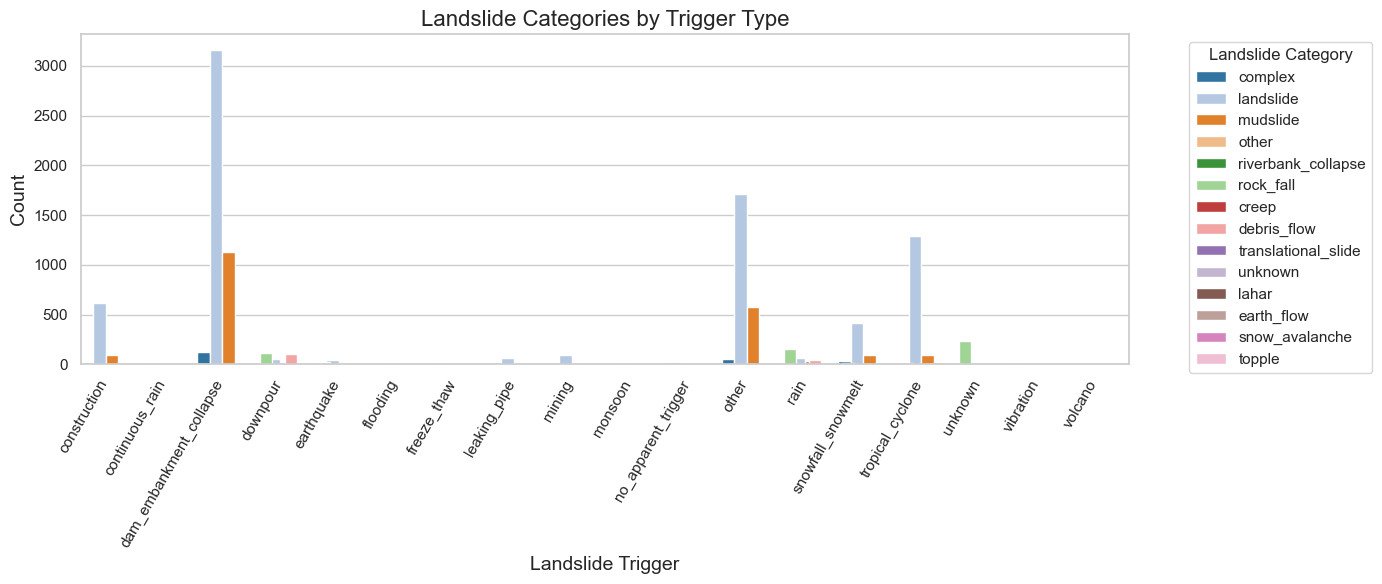

In [223]:
plt.figure(figsize=(14,6))
sns.barplot(
    data=trigger_counts,
    x="landslide_trigger", y="count", hue="landslide_category",
    palette="tab20", width=3
)
plt.xticks(rotation=60, ha="right")
plt.title("Landslide Categories by Trigger Type", fontsize=16)
plt.xlabel("Landslide Trigger", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.legend(title="Landslide Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

This chart counts events by trigger (x-axis) and breaks them out by landslide category. “Downpour” is the most common trigger overall—especially for the broad **landslide** and **mudslide** categories—while **rain** and **tropical_cyclone** also contribute many events. Triggers like **earthquake**, **volcano**, and **construction** appear far less frequently, and a notable share of records remain in **other/unknown** triggers.

In [224]:
# Work on a copy to avoid altering the original cleaned dataset
df = clean_landslides.copy()

In [225]:
# Map months -> seasons
season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
}
df["season"] = df["event_month"].map(season_map)

In [226]:
# Filter triggers
exclude = {"other", "no_apparent_trigger", "unknown"}
plot_df = df[df["landslide_trigger"].notna() & ~df["landslide_trigger"].isin(exclude)]

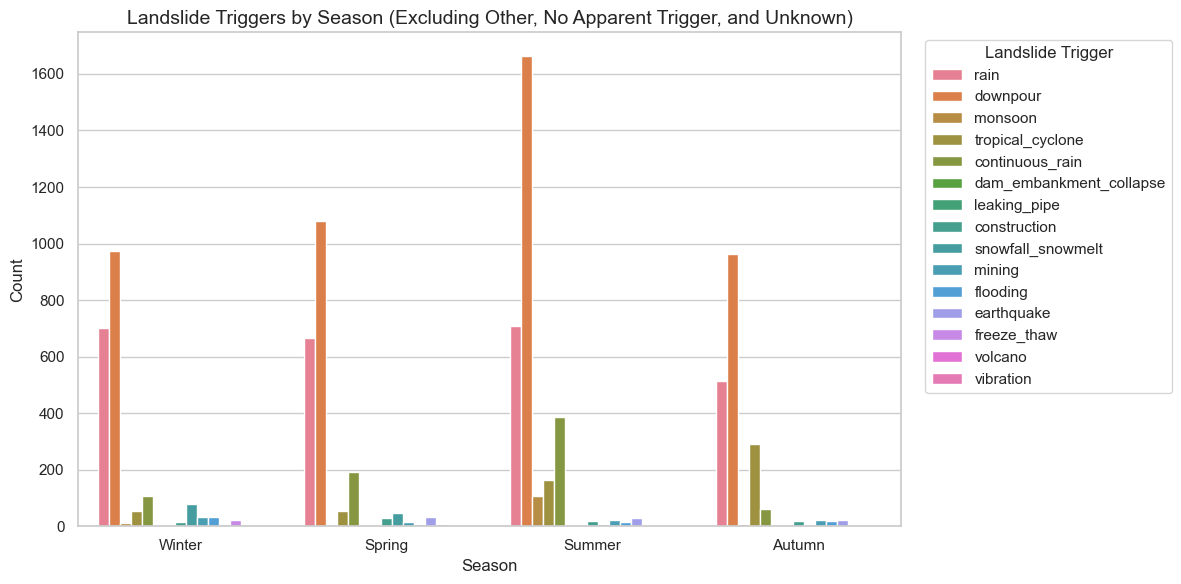

In [227]:
# Plot 
plt.figure(figsize=(12,6))
sns.countplot(
    data=plot_df,
    x="season",
    hue="landslide_trigger",
    order=["Winter","Spring","Summer","Autumn"]
)
plt.title("Landslide Triggers by Season (Excluding Other, No Apparent Trigger, and Unknown)", fontsize=14)
plt.xlabel("Season")
plt.ylabel("Count")
plt.legend(title="Landslide Trigger", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

This chart shows landslide triggers aggregated by season, after mapping event months (1–12) into Winter, Spring, Summer, and Autumn. The results highlight clear seasonal patterns: **downpours** and **rain** dominate across all seasons, with the highest concentration occurring in **summer**. Monsoons and tropical cyclones also peak in summer, while winter and autumn show fewer events overall.  

These findings emphasize the strong link between rainfall-related triggers and seasonal weather patterns, with summer standing out as the riskiest period for severe landslide activity.  

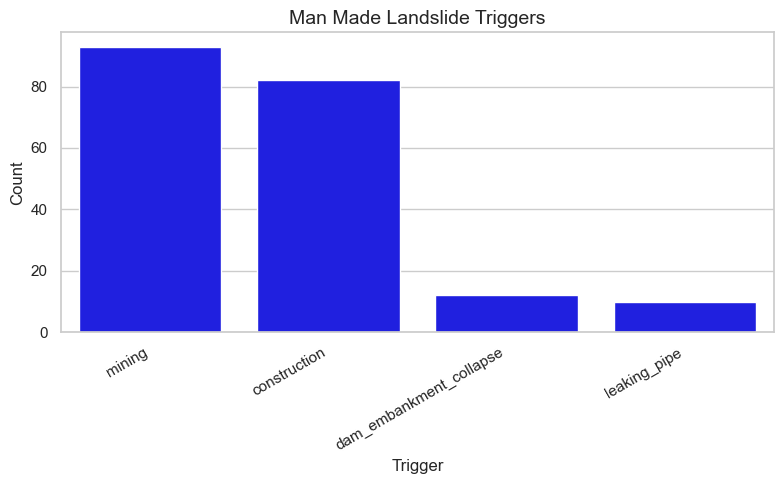

In [228]:
# Filter for manmade triggers
manmade_triggers = ["dam_embankment_collapse", "leaking_pipe", "construction", "mining"]
manmadeslides = clean_landslides[clean_landslides["landslide_trigger"].isin(manmade_triggers)]

# Count occurrences of each trigger
trigger_counts = manmadeslides["landslide_trigger"].value_counts().reset_index()
trigger_counts.columns = ["landslide_trigger", "count"]

# Bar chart
plt.figure(figsize=(8,5))
sns.barplot(data=trigger_counts, x="landslide_trigger", y="count", color="blue")

plt.title("Man Made Landslide Triggers", fontsize=14)
plt.xlabel("Trigger")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [229]:
# Calculate mining percentage of all man-made events
total_target_count = trigger_counts["count"].sum()
mining_count = trigger_counts.loc[trigger_counts["landslide_trigger"] == "mining", "count"].iloc[0]
percentage_mining = (mining_count / total_target_count) * 100

print(f"Mining makes up {percentage_mining:.2f}% of man-made landslide events")

Mining makes up 47.21% of man-made landslide events


Among man-made triggers, **mining** and **construction** dominate, together accounting for the vast majority of recorded events. Mining alone makes up nearly half of all man-made landslides (47.2%). Less frequent triggers include **dam embankment collapse** and **leaking pipes**, which appear rarely in the dataset. These results show that human activity—especially resource extraction and large-scale building—plays a significant role in landslide occurrence compared to other man-made causes. 

## NASA POWER Rainfall Data: Cleaning, Processing, and Analysis

In [230]:
# Load rainfall dataset
rainfall_df = pd.read_csv("Rainfall_data.csv")

In [231]:
# Quick check
print(rainfall_df.shape)   # rows, columns
print(rainfall_df.columns) # column names
rainfall_df.head(50)

(252, 7)
Index(['Year', 'Month', 'Day', 'Specific Humidity', 'Relative Humidity',
       'Temperature', 'Precipitation'],
      dtype='object')


,Year,Month,Day,Specific Humidity,Relative Humidity,Temperature,Precipitation
0,2000,1,1,8.06,48.25,23.93,0.00
1,2000,2,1,8.73,50.81,25.83,0.11
2,2000,3,1,8.48,42.88,26.68,0.01
3,2000,4,1,13.79,55.69,22.49,0.02
4,2000,5,1,17.40,70.88,19.07,271.14
5,2000,6,1,19.53,84.19,7.91,313.67
6,2000,7,1,18.80,88.50,6.67,820.45
7,2000,8,1,18.86,88.44,7.07,362.38
8,2000,9,1,18.43,86.12,10.63,97.85
9,2000,10,1,16.72,78.38,15.38,63.41


The dataset contains daily weather records from the year 2000 onward, with variables such as specific humidity, relative humidity, temperature, and precipitation. This information will be used to examine environmental factors that may influence landslide activity.  

In [232]:
# Ensure Precipitation is numeric
rainfall_df["Precipitation"] = pd.to_numeric(rainfall_df["Precipitation"], errors="coerce")

# Aggregate annual precipitation (sum of daily values)
annual_rainfall = (
    rainfall_df.groupby("Year")["Precipitation"]
    .sum()
    .reset_index()
    .rename(columns={"Precipitation": "Annual_Precipitation"})
)

In [233]:
# Count landslides per year
landslides_per_year = (
    clean_landslides
    .groupby("event_year")
    .size()
    .reset_index(name="Landslide_Count")
)

# merging the two datasets
merged = pd.merge(
    landslides_per_year, 
    annual_rainfall, 
    left_on="event_year", 
    right_on="Year", 
    how="inner"
)

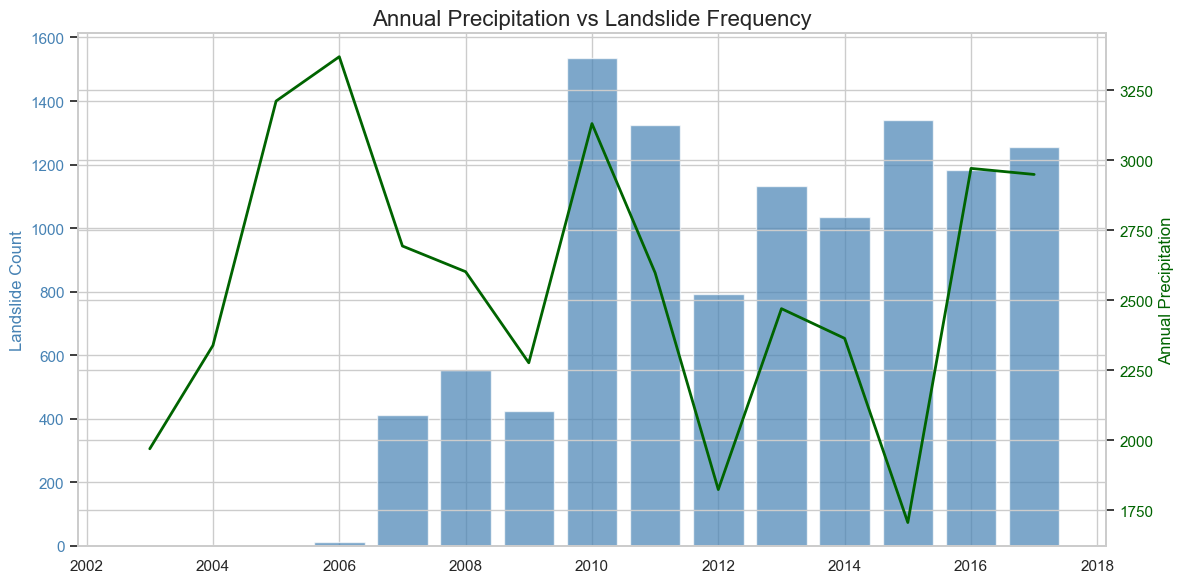

In [234]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Bars: landslide counts
ax1.bar(merged["event_year"], merged["Landslide_Count"], 
        color="steelblue", alpha=0.7, label="Landslides")
ax1.set_ylabel("Landslide Count", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

# Line: precipitation
ax2 = ax1.twinx()
ax2.plot(merged["event_year"], merged["Annual_Precipitation"], 
         color="darkgreen", linewidth=2, label="Annual Precipitation")
ax2.set_ylabel("Annual Precipitation", color="darkgreen")
ax2.tick_params(axis="y", labelcolor="darkgreen")

plt.title("Annual Precipitation vs Landslide Frequency", fontsize=16)
fig.tight_layout()
plt.show()

In [235]:
corr = merged[["Landslide_Count", "Annual_Precipitation"]].corr().iloc[0,1]
print(f"Correlation between rainfall and landslides: {corr:.2f}")

Correlation between rainfall and landslides: -0.06


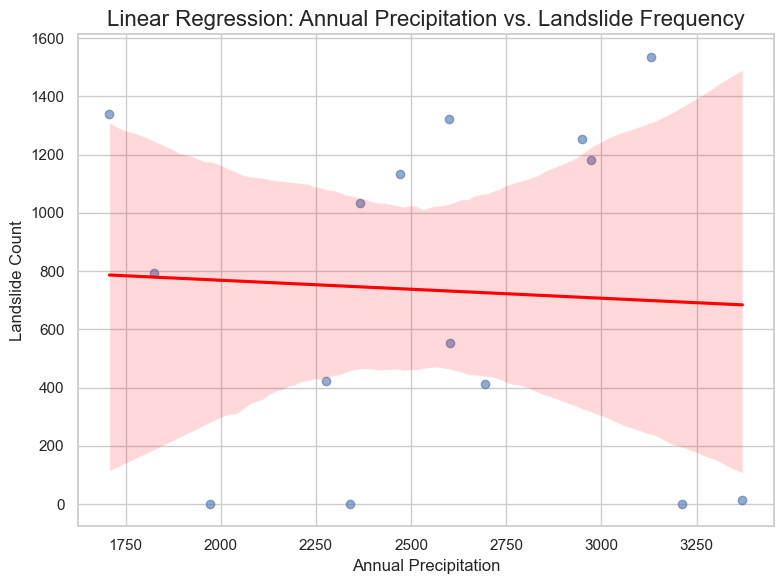

In [236]:
plt.figure(figsize=(8,6))
sns.regplot(
    data=merged,
    x="Annual_Precipitation",
    y="Landslide_Count",
    scatter_kws={"alpha":0.6},
    line_kws={"color":"red"}
)

plt.title("Linear Regression: Annual Precipitation vs. Landslide Frequency", fontsize=16)
plt.xlabel("Annual Precipitation")
plt.ylabel("Landslide Count")
plt.tight_layout()
plt.show()

In [237]:
# Run linear regression
x = merged["Annual_Precipitation"]
y = merged["Landslide_Count"]

slope, intercept, r_value, p_value, std_err = linregress(x, y)

print(f"Regression equation: y = {slope:.4f}x + {intercept:.2f}")
print(f"R²: {r_value**2:.4f}")
print(f"Slope (coefficient): {slope:.4f}")
print(f"Intercept: {intercept:.2f}")
print(f"P-value: {p_value:.4f}")
print(f"Standard Error: {std_err:.4f}")

Regression equation: y = -0.0617x + 891.95
R²: 0.0030
Slope (coefficient): -0.0617
Intercept: 891.95
P-value: 0.8456
Standard Error: 0.3103


To explore whether rainfall influences landslide activity, the NASA POWER rainfall dataset was merged with the Global Landslide Catalog.  

The first chart compares **annual precipitation (green line)** with **annual landslide counts (blue bars)**. While there are years where both appear elevated (e.g., 2010–2011), overall the patterns do not align strongly, suggesting rainfall alone may not explain fluctuations in landslide frequency.  

The second chart applies a simple **linear regression** to quantify this relationship. The regression line has a very shallow negative slope (−0.06), an extremely low R² value (0.003), and a high p-value (0.846). These results confirm there is **no statistically significant correlation** between total annual precipitation and the number of reported landslides in this dataset.  

Introducing the rainfall dataset therefore provided useful context, but the analysis shows that landslides cannot be explained by precipitation totals alone. Other factors—such as event triggers, local geography, or reporting bias—are likely more important drivers in the dataset.  

## Conclusion

This project explored global landslide patterns using the NASA Global Landslide Catalog and later introduced rainfall data from NASA POWER to test for environmental connections. The analysis showed that broad “landslide” and “mudslide” categories account for most fatalities, with rainfall-related triggers such as downpours, monsoons, and tropical cyclones dominating across seasons. Rare but catastrophic events, like the 2013 debris flow in India that killed 5,000 people, illustrate the devastating potential of very large landslides. Man-made triggers, particularly mining and construction, also emerged as important contributors. When rainfall data was incorporated, the results revealed almost no statistical relationship between annual precipitation and landslide frequency, suggesting that precipitation totals alone cannot explain global landslide activity. This underscores the importance of more comprehensive, multi-variable datasets that incorporate factors such as soil type, slope, land use, and localized weather extremes, while also acknowledging that many landslides go unreported and global risk is therefore underestimated. Ultimately, the findings show that landslide hazards are complex phenomena, shaped by the interplay of natural processes, human activity, and data limitations rather than any single driver.